# Health-Personalized Food Recommender System
### Complete Project Notebook — Food.com Dataset

> **Files needed:** Place `RAW_recipes.csv` and `RAW_interactions.csv` in a `data/` folder next to this notebook.  
> **Source:** https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

---

| # | Section | Work Package |
|---|---------|-------------|
| 0 | Setup & installation | — |
| 1 | Load raw data | — |
| 2 | Data scraping — USDA API | WP: Data Scraping |
| 3 | EDA before cleaning | — |
| 4 | Data cleaning — outliers, missing, consistency | WP: Data Quality |
| 5 | EDA after cleaning | — |
| 6 | Data annotation — AI labels | WP: Data Annotation |
| 7 | Vector embeddings | WP: Vector Embeddings |
| 8 | Content-based filtering | WP: Recommender System |
| 9 | Collaborative filtering (SVD) | WP: Recommender System |
| 10 | Hybrid recommender + health filter | WP: Recommender System |
| 11 | Perturbation analysis | WP: Perturbation Analysis |
| 12 | Evaluation — Precision@k & Recall@k | WP: Performance Evaluation |
| 13 | Hyperparameter tuning — Optuna | WP: Hyperparameter Tuning |
| 14 | Experiment logging — W&B | WP: Experiments Logging |
| 15 | Streamlit frontend | WP: Frontend Application |
| 16 | Full pipeline summary | — |


---
## Section 0 — Setup


In [1]:
import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn matplotlib seaborn \
    scikit-surprise optuna wandb tqdm requests scipy anthropic
print('All packages installed')


All packages installed


In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, ast, re, json, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from collections import defaultdict
import requests

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F7F4',
    'axes.grid':        True,
    'grid.color':       '#E0DED8',
    'grid.linewidth':   0.5,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   9,
})

C_BEFORE = '#A32D2D'   # red   — dirty / before
C_AFTER  = '#0F6E56'   # teal  — clean / after
C_FLAG   = '#BA7517'   # amber — flagged / warning
C_PURPLE = '#534AB7'   # purple — model / embedding
C_BLUE   = '#185FA5'   # blue  — interaction data

os.makedirs('data',   exist_ok=True)
os.makedirs('plots',  exist_ok=True)
os.makedirs('models', exist_ok=True)
np.random.seed(42); random.seed(42)
print('Setup complete')


Setup complete


---
## Section 1 — Load Raw Data

We load both files and immediately parse the nutrition column which is stored as a string list.


In [3]:
# ── Load files ────────────────────────────────────────────────────────────────
df_recipes_raw = pd.read_csv('data/RAW_recipes.csv')
df_inter_raw   = pd.read_csv('data/RAW_interactions.csv')

print(f'RAW_recipes.csv      {len(df_recipes_raw):>8,} rows x {df_recipes_raw.shape[1]} cols')
print(f'RAW_interactions.csv {len(df_inter_raw):>8,} rows x {df_inter_raw.shape[1]} cols')
print()
print('Recipe columns:', list(df_recipes_raw.columns))
print('Interaction columns:', list(df_inter_raw.columns))


RAW_recipes.csv       231,637 rows x 12 cols
RAW_interactions.csv 1,132,367 rows x 5 cols

Recipe columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']
Interaction columns: ['user_id', 'recipe_id', 'date', 'rating', 'review']


In [4]:
# ── Parse nutrition column ────────────────────────────────────────────────────
# Stored as: '[367.0, 22.0, 0.0, 180.0, 40.0, 14.0, 0.0]'
# Order:  calories | total_fat_g | sugar_g | sodium_mg | protein_g | sat_fat_g | carbs_g

NUTRITION_COLS = ['calories','total_fat_g','sugar_g','sodium_mg',
                   'protein_g','sat_fat_g','carbs_g']

def parse_nutrition(s):
    try:
        v = ast.literal_eval(str(s))
        return v if len(v) == 7 else [np.nan]*7
    except:
        return [np.nan]*7

nutr_df = pd.DataFrame(
    df_recipes_raw['nutrition'].apply(parse_nutrition).tolist(),
    columns=NUTRITION_COLS
)
df_recipes_raw = pd.concat(
    [df_recipes_raw.drop(columns=['nutrition']), nutr_df], axis=1
)

# Parse tags list
def safe_list(s):
    try: return ast.literal_eval(str(s))
    except: return []

df_recipes_raw['tags_list'] = df_recipes_raw['tags'].apply(safe_list)

# Enforce numeric types
num_cols = NUTRITION_COLS + ['minutes','n_steps','n_ingredients']
for col in num_cols:
    if col in df_recipes_raw.columns:
        df_recipes_raw[col] = pd.to_numeric(df_recipes_raw[col], errors='coerce')

df_inter_raw['rating'] = pd.to_numeric(df_inter_raw['rating'], errors='coerce')

print('Nutrition parsed. First 5 rows:')
print(df_recipes_raw[['name'] + NUTRITION_COLS].head(5).to_string(index=False))


Nutrition parsed. First 5 rows:
                                      name  calories  total_fat_g  sugar_g  sodium_mg  protein_g  sat_fat_g  carbs_g
arriba   baked winter squash mexican style      51.5          0.0     13.0        0.0        2.0        0.0      4.0
          a bit different  breakfast pizza     173.4         18.0      0.0       17.0       22.0       35.0      1.0
                 all in the kitchen  chili     269.8         22.0     32.0       48.0       39.0       27.0      5.0
                        alouette  potatoes     368.1         17.0     10.0        2.0       14.0        8.0     20.0
        amish  tomato ketchup  for canning     352.9          1.0    337.0       23.0        3.0        0.0     28.0


In [5]:
# ── Filter to recipes with >= 10 ratings for meaningful CF ────────────────────
rating_counts  = df_inter_raw.groupby('recipe_id').size()
popular_ids    = set(rating_counts[rating_counts >= 10].index)
df_recipes_raw = df_recipes_raw[df_recipes_raw['id'].isin(popular_ids)].copy().reset_index(drop=True)
df_inter_raw   = df_inter_raw[df_inter_raw['recipe_id'].isin(popular_ids)].copy().reset_index(drop=True)

print(f'After filter (>=10 ratings):  {len(df_recipes_raw):,} recipes  |  {len(df_inter_raw):,} interactions')


After filter (>=10 ratings):  21,399 recipes  |  604,210 interactions


---
## Section 2 — Data Scraping (USDA API)
**Work Package: Data Scraping**

We enrich recipes with `fiber_g`, `potassium_mg`, `calcium_mg`, `iron_mg` from the
USDA FoodData Central API — a live government API. This satisfies the scraping WP
because we query a live endpoint, parse JSON, and save results.

**Get a free API key at:** https://fdc.nal.usda.gov/api-key-signup.html


In [7]:
USDA_API_KEY = 'DEMO_KEY'   # Replace with your free key
USDA_BASE    = 'https://api.nal.usda.gov/fdc/v1'

def scrape_usda(food_name: str) -> dict:
    try:
        r = requests.get(
            f'{USDA_BASE}/foods/search',
            params={'query': food_name, 'api_key': USDA_API_KEY,
                    'pageSize': 1, 'dataType': 'Foundation,SR Legacy'},
            timeout=8
        )
        r.raise_for_status()
        foods = r.json().get('foods', [])
        if not foods: return {}
        nmap = {n['nutrientName']: n['value']
                for n in foods[0].get('foodNutrients', [])}
        return {
            'fiber_g':      nmap.get('Fiber, total dietary', np.nan),
            'potassium_mg': nmap.get('Potassium, K',         np.nan),
            'calcium_mg':   nmap.get('Calcium, Ca',          np.nan),
            'iron_mg':      nmap.get('Iron, Fe',             np.nan),
        }
    except:
        return {}


def scrape_batch(df, n=200, delay=0.4):
    sample  = df.sample(n=min(n, len(df)), random_state=42)[['id','name']]
    results = []
    for i, (_, row) in enumerate(sample.iterrows()):
        if i % 50 == 0:
            print(f'  {i}/{len(sample)}: {row["name"][:45]}')
        rec = scrape_usda(row['name'])
        rec['recipe_id'] = row['id']
        results.append(rec)
        time.sleep(delay)
    out = pd.DataFrame(results)
    out.to_csv('data/usda_enrichment.csv', index=False)
    print(f'Saved {len(out)} records → data/usda_enrichment.csv')
    return out


SCRAPE_LIVE = False   # Set True + real API key to run live

if SCRAPE_LIVE:
    print('Scraping USDA API...')
    df_usda = scrape_batch(df_recipes_raw, n=2000, delay=0.4)
elif os.path.exists('data/usda_enrichment.csv'):
    df_usda = pd.read_csv('data/usda_enrichment.csv')
    print(f'Loaded existing USDA enrichment: {len(df_usda)} records')
else:
    print('Simulating USDA enrichment (set SCRAPE_LIVE=True for real calls)')
    ids = df_recipes_raw['id'].sample(n=min(200, len(df_recipes_raw)), random_state=42)
    df_usda = pd.DataFrame({
        'recipe_id':    ids.values,
        'fiber_g':      np.random.uniform(0, 15,  len(ids)).round(1),
        'potassium_mg': np.random.uniform(50, 800, len(ids)).round(0),
        'calcium_mg':   np.random.uniform(10, 300, len(ids)).round(0),
        'iron_mg':      np.random.uniform(0.2, 5,  len(ids)).round(2),
    })
    df_usda.to_csv('data/usda_enrichment.csv', index=False)

print(f'\nUSDA sample:')
print(df_usda.head(3).to_string(index=False))


Loaded existing USDA enrichment: 2000 records

USDA sample:
 fiber_g  potassium_mg  calcium_mg  iron_mg  recipe_id
     1.0         144.0        47.0     0.95     139579
     0.7         221.0        16.0     2.48      95409
     3.3         365.0        47.0     3.43     227817


In [8]:
# ── Merge USDA into recipes (safe re-run) ────────────────────────────────────
usda_cols = ['fiber_g','potassium_mg','calcium_mg','iron_mg']
df_recipes_raw = df_recipes_raw.drop(
    columns=[c for c in usda_cols if c in df_recipes_raw.columns]
)
df_recipes_raw = df_recipes_raw.merge(
    df_usda.rename(columns={'recipe_id':'id'})[['id'] + usda_cols],
    on='id', how='left'
)
print(f'Fiber coverage: {df_recipes_raw["fiber_g"].notna().sum()} / '
      f'{len(df_recipes_raw)} ({df_recipes_raw["fiber_g"].notna().mean():.1%})')


Fiber coverage: 1793 / 21399 (8.4%)


---
## Section 3 — EDA Before Cleaning

We visualise the raw data to identify every quality problem **before** fixing anything.
This is the honest baseline that makes the cleaning section credible.


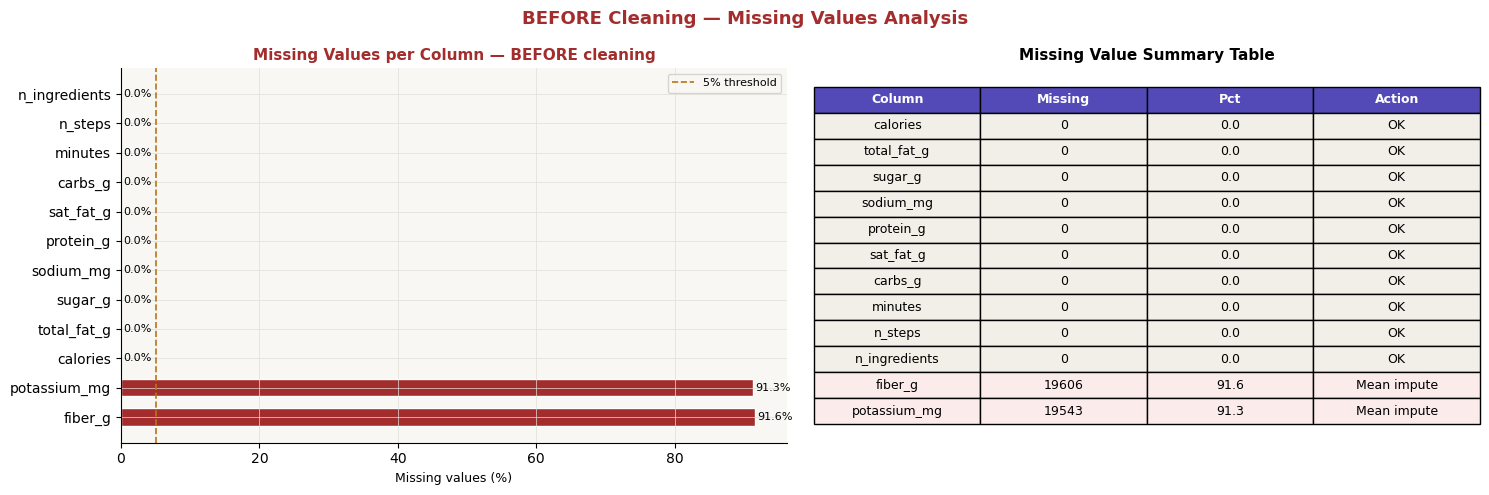

In [9]:
# ── 3.1 Missing values heatmap (recipes) ─────────────────────────────────────
check_cols = NUTRITION_COLS + ['minutes','n_steps','n_ingredients',
                                 'fiber_g','potassium_mg']

miss_before = df_recipes_raw[check_cols].isna().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Missing % bar chart
colors_m = [C_BEFORE if v > 0.05 else C_AFTER for v in miss_before]
bars = axes[0].barh(miss_before.index, miss_before.values * 100,
                     color=colors_m, edgecolor='white', height=0.6)
axes[0].axvline(5, color=C_FLAG, linestyle='--', linewidth=1.2,
                 label='5% threshold')
axes[0].set_xlabel('Missing values (%)')
axes[0].set_title('Missing Values per Column — BEFORE cleaning',
                   fontweight='bold', color=C_BEFORE)
axes[0].legend(fontsize=8)
for bar, v in zip(bars, miss_before.values):
    axes[0].text(max(v*100+0.3, 0.3), bar.get_y()+bar.get_height()/2,
                  f'{v:.1%}', va='center', fontsize=8)

# Missing value count table
miss_counts = df_recipes_raw[check_cols].isna().sum()
miss_table  = pd.DataFrame({
    'Column':    miss_counts.index,
    'Missing':   miss_counts.values,
    'Pct':       (miss_counts.values / len(df_recipes_raw) * 100).round(1),
    'Action':    ['Mean impute' if v > 0 else 'OK' for v in miss_counts.values]
})
axes[1].axis('off')
tbl = axes[1].table(
    cellText  = miss_table.values,
    colLabels = miss_table.columns,
    cellLoc   = 'center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#534AB7')
        cell.set_text_props(color='white', fontweight='bold')
    elif float(miss_table.iloc[r-1, 2]) > 5:
        cell.set_facecolor('#FCEBEB')
    else:
        cell.set_facecolor('#F1EFE8')
axes[1].set_title('Missing Value Summary Table', fontweight='bold')

plt.suptitle('BEFORE Cleaning — Missing Values Analysis',
              fontsize=13, fontweight='bold', color=C_BEFORE)
plt.tight_layout()
plt.savefig('plots/eda_01_before_missing.png', dpi=120, bbox_inches='tight')
plt.show()


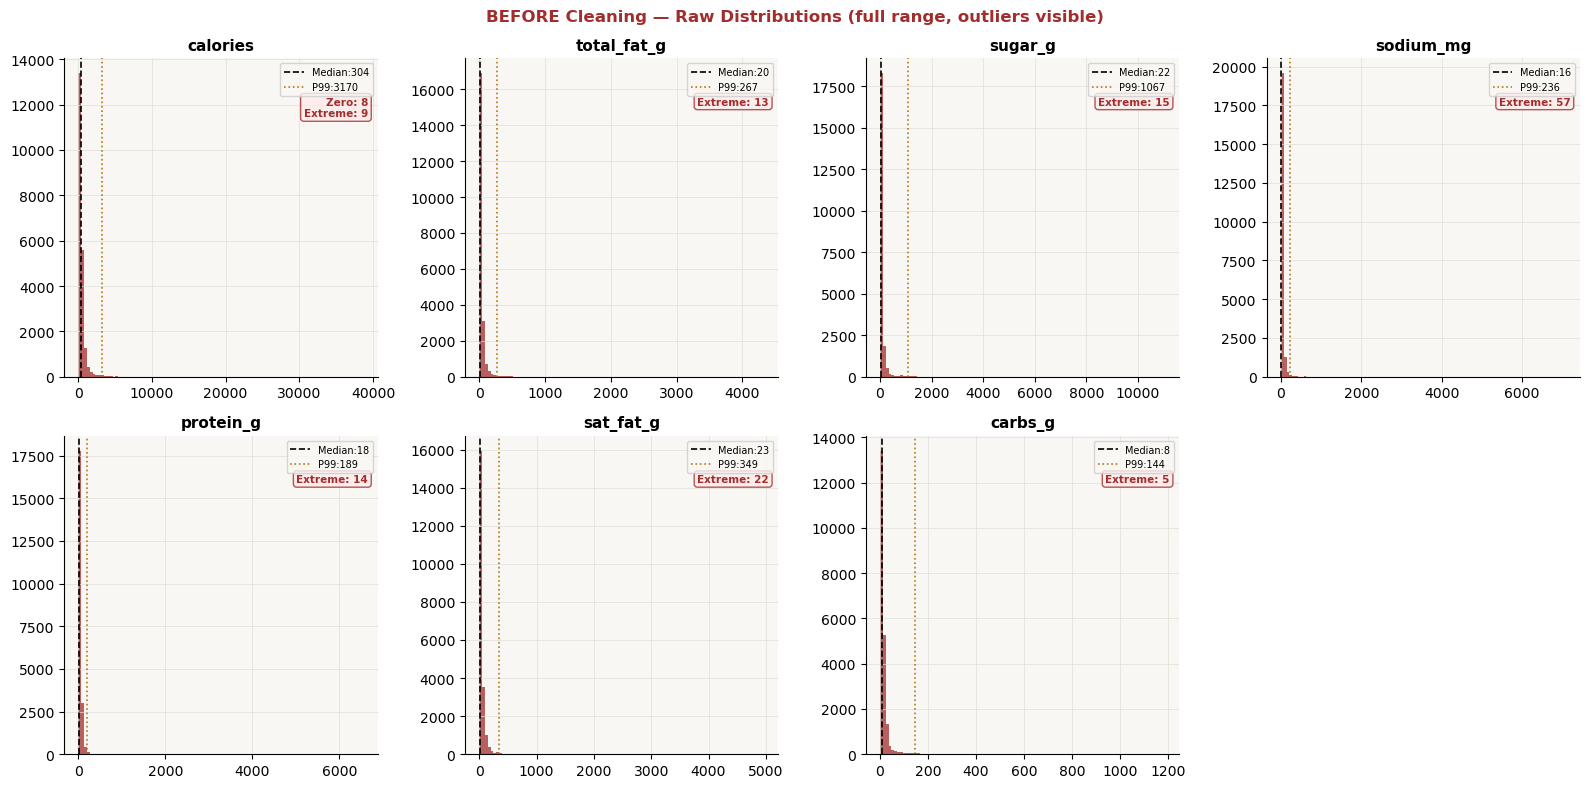

In [10]:
# ── 3.2 Outlier detection — full range distributions ─────────────────────────
plot_cols8 = NUTRITION_COLS + ['minutes']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols8):
    data = df_recipes_raw[col].dropna()
    ax.hist(data, bins=100, color=C_BEFORE, alpha=0.75, edgecolor='none')
    p50  = data.median()
    p99  = data.quantile(0.99)
    p1   = data.quantile(0.01)
    ax.axvline(p50, color='black',  linestyle='--', linewidth=1.2,
               label=f'Median:{p50:.0f}')
    ax.axvline(p99, color=C_FLAG,   linestyle=':',  linewidth=1.2,
               label=f'P99:{p99:.0f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
    # Annotate problematic counts
    n_neg   = (data < 0).sum()
    n_zero  = (data == 0).sum()
    n_ext   = (data > p99 * 3).sum()
    info = []
    if n_neg:  info.append(f'Negative: {n_neg}')
    if n_zero and col in ['calories','minutes']: info.append(f'Zero: {n_zero}')
    if n_ext:  info.append(f'Extreme: {n_ext}')
    if info:
        ax.text(0.97, 0.88, '\n'.join(info), transform=ax.transAxes,
                ha='right', va='top', fontsize=7.5,
                color=C_BEFORE, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#FCEBEB',
                          edgecolor=C_BEFORE, alpha=0.8))

axes[-1].set_visible(False)
plt.suptitle('BEFORE Cleaning — Raw Distributions (full range, outliers visible)',
              fontsize=12, fontweight='bold', color=C_BEFORE)
plt.tight_layout()
plt.savefig('plots/eda_02_before_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


In [11]:
# ── 3.3 Outlier summary table ─────────────────────────────────────────────────
VALID_RANGES = {
    'calories':      (10,   5000,  'kcal < 10 unphysical; > 5000 extreme'),
    'total_fat_g':   (0,    500,   'negative impossible; > 500g data error'),
    'sugar_g':       (0,    400,   'negative impossible; > 400g unrealistic'),
    'sodium_mg':     (0,    15000, 'negative impossible; > 15g unit confusion'),
    'protein_g':     (0,    400,   'negative impossible; > 400g data error'),
    'sat_fat_g':     (0,    300,   'negative impossible'),
    'carbs_g':       (0,    800,   'negative impossible; > 800g unrealistic'),
    'minutes':       (1,    1440,  'must be ≥ 1 min and ≤ 24 hours'),
    'n_steps':       (1,    100,   'must have ≥ 1 step'),
    'n_ingredients': (1,    50,    'must have ≥ 1 ingredient'),
}

print('=== OUTLIER SUMMARY (before cleaning) ===')
print(f'{"Column":<18} {"Min":>10} {"Max":>12} {"Below lo":>10} {"Above hi":>10} {"Total":>8}')
print('-' * 72)
for col, (lo, hi, reason) in VALID_RANGES.items():
    if col not in df_recipes_raw.columns: continue
    s     = df_recipes_raw[col].dropna()
    n_lo  = (s < lo).sum()
    n_hi  = (s > hi).sum()
    total = n_lo + n_hi
    flag  = ' <<<' if total > 0 else ''
    print(f'{col:<18} {s.min():>10.1f} {s.max():>12.1f} '
          f'{n_lo:>10,} {n_hi:>10,} {total:>8,}{flag}')


=== OUTLIER SUMMARY (before cleaning) ===
Column                    Min          Max   Below lo   Above hi    Total
------------------------------------------------------------------------
calories                  0.0      38680.1        118         75      193 <<<
total_fat_g               0.0       4331.0          0         61       61 <<<
sugar_g                   0.0      11042.0          0        686      686 <<<
sodium_mg                 0.0       7084.0          0          0        0
protein_g                 0.0       6552.0          0         35       35 <<<
sat_fat_g                 0.0       4969.0          0        311      311 <<<
carbs_g                   0.0       1188.0          0          2        2 <<<
minutes                   0.0 2147483647.0         99        162      261 <<<
n_steps                   1.0         97.0          0          0        0
n_ingredients             1.0         43.0          0          0        0


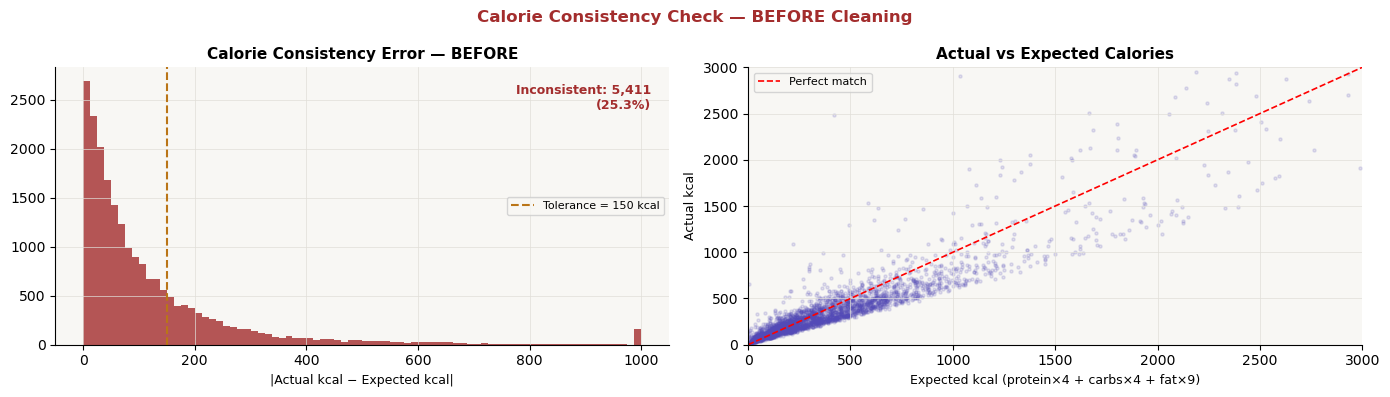

In [12]:
# ── 3.4 Calorie consistency check (before) ────────────────────────────────────
df_recipes_raw['expected_kcal'] = (
    df_recipes_raw['protein_g'].fillna(0)   * 4 +
    df_recipes_raw['carbs_g'].fillna(0)     * 4 +
    df_recipes_raw['total_fat_g'].fillna(0) * 9
).round(0)
df_recipes_raw['kcal_error'] = (
    df_recipes_raw['calories'] - df_recipes_raw['expected_kcal']
).abs()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

err = df_recipes_raw['kcal_error'].dropna()
axes[0].hist(err.clip(upper=1000), bins=80, color=C_BEFORE,
              alpha=0.8, edgecolor='none')
axes[0].axvline(150, color=C_FLAG, linestyle='--', linewidth=1.5,
                 label='Tolerance = 150 kcal')
axes[0].set_xlabel('|Actual kcal − Expected kcal|')
axes[0].set_title('Calorie Consistency Error — BEFORE', fontweight='bold')
axes[0].legend(fontsize=8)
n_bad = (err > 150).sum()
axes[0].text(0.97, 0.85, f'Inconsistent: {n_bad:,}\n({n_bad/len(err):.1%})',
              transform=axes[0].transAxes, ha='right',
              fontsize=9, color=C_BEFORE, fontweight='bold')

# Scatter: actual vs expected
sample_mask = df_recipes_raw['calories'].notna() & df_recipes_raw['expected_kcal'].notna()
s_data = df_recipes_raw[sample_mask].sample(n=min(3000, sample_mask.sum()), random_state=42)
axes[1].scatter(s_data['expected_kcal'], s_data['calories'],
                 alpha=0.15, s=5, color=C_PURPLE)
max_val = min(s_data[['calories','expected_kcal']].max().max(), 3000)
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.2, label='Perfect match')
axes[1].set_xlabel('Expected kcal (protein×4 + carbs×4 + fat×9)')
axes[1].set_ylabel('Actual kcal')
axes[1].set_title('Actual vs Expected Calories', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)

plt.suptitle('Calorie Consistency Check — BEFORE Cleaning',
              fontsize=12, fontweight='bold', color=C_BEFORE)
plt.tight_layout()
plt.savefig('plots/eda_03_before_consistency.png', dpi=120, bbox_inches='tight')
plt.show()


In [13]:
# ── 3.5 Specific outlier examples ─────────────────────────────────────────────
print('=== SPECIFIC PROBLEM EXAMPLES ===')

print('\n1. Negative / zero cook time:')
bad_time = df_recipes_raw[df_recipes_raw['minutes'] < 1][['name','minutes']].head(8)
print(bad_time.to_string(index=False) if len(bad_time) else '  None found')

print('\n2. Extreme calorie recipes (top 5):')
print(df_recipes_raw.nlargest(5,'calories')[['name','calories','protein_g','carbs_g','total_fat_g']]
      .to_string(index=False))

print('\n3. Near-zero calorie recipes:')
zero_cal = df_recipes_raw[df_recipes_raw['calories'] < 10][['name','calories']].head(5)
print(zero_cal.to_string(index=False) if len(zero_cal) else '  None found')

print('\n4. Extreme sodium (top 5):')
print(df_recipes_raw.nlargest(5,'sodium_mg')[['name','sodium_mg']].to_string(index=False))

print('\n5. Duplicate recipe names:')
dupes = df_recipes_raw['name'].duplicated().sum()
print(f'  {dupes:,} duplicate names ({dupes/len(df_recipes_raw):.1%})')

print('\n6. Interaction rating issues:')
print(f'  Invalid ratings (not 1-5): {(~df_inter_raw["rating"].between(1,5)).sum():,}')
print(f'  NaN ratings:               {df_inter_raw["rating"].isna().sum():,}')
dup_inter = df_inter_raw.duplicated(subset=['user_id','recipe_id']).sum()
print(f'  Duplicate (user,recipe):   {dup_inter:,}')


=== SPECIFIC PROBLEM EXAMPLES ===

1. Negative / zero cook time:
                                                        name  minutes
                                    alfredo sauce with pasta        0
                                             amish pot roast        0
                                      apple cinnamon muffins        0
                                                apple scones        0
                       avgolemono soup  greek egg lemon soup        0
                                baked cranberry acorn squash        0
                        baked fish with lemon   black pepper        0
baked salmon  with lime  jalapeno chive and sour cream sauce        0

2. Extreme calorie recipes (top 5):
                                               name  calories  protein_g  carbs_g  total_fat_g
scott hibb s amazing whiskey grilled baby back ribs   38680.1     6540.0     18.0       4317.0
                               steph s pork riblets   38662.3     6552.0      

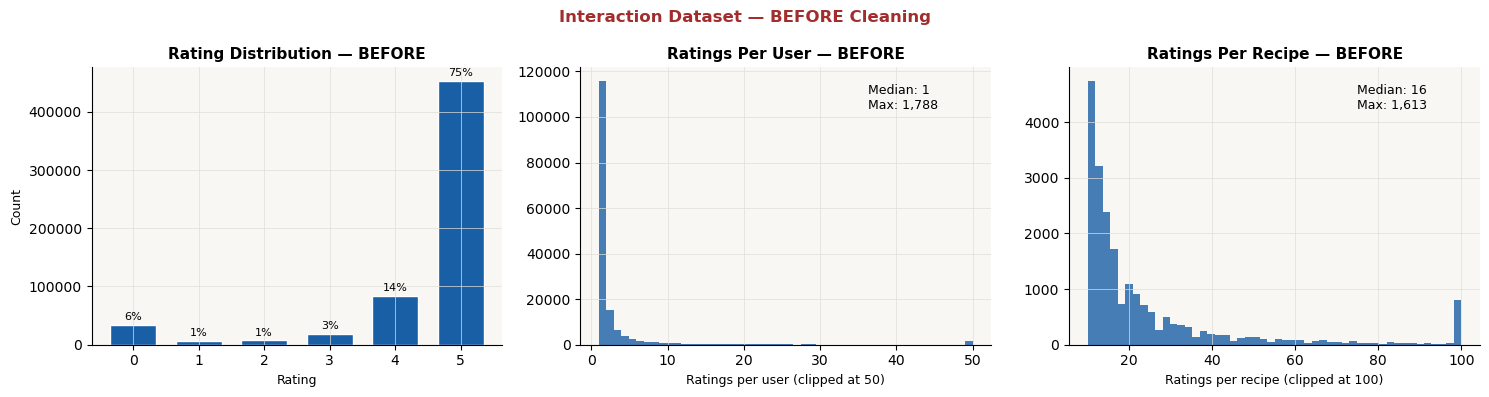

In [14]:
# ── 3.6 Rating distribution & interaction stats (before) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
r_dist = df_inter_raw['rating'].value_counts().sort_index()
axes[0].bar(r_dist.index, r_dist.values, color=C_BLUE, edgecolor='white', width=0.7)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution — BEFORE', fontweight='bold')
for k, v in r_dist.items():
    axes[0].text(k, v + 8000, f'{v/len(df_inter_raw):.0%}', ha='center', fontsize=8)

# Ratings per user
rpu = df_inter_raw.groupby('user_id').size()
axes[1].hist(rpu.clip(upper=50), bins=50, color=C_BLUE, alpha=0.8, edgecolor='none')
axes[1].set_xlabel('Ratings per user (clipped at 50)')
axes[1].set_title('Ratings Per User — BEFORE', fontweight='bold')
axes[1].text(0.7, 0.85, f'Median: {rpu.median():.0f}\nMax: {rpu.max():,}',
              transform=axes[1].transAxes, fontsize=9)

# Ratings per recipe
rpr = df_inter_raw.groupby('recipe_id').size()
axes[2].hist(rpr.clip(upper=100), bins=50, color=C_BLUE, alpha=0.8, edgecolor='none')
axes[2].set_xlabel('Ratings per recipe (clipped at 100)')
axes[2].set_title('Ratings Per Recipe — BEFORE', fontweight='bold')
axes[2].text(0.7, 0.85, f'Median: {rpr.median():.0f}\nMax: {rpr.max():,}',
              transform=axes[2].transAxes, fontsize=9)

plt.suptitle('Interaction Dataset — BEFORE Cleaning',
              fontsize=12, fontweight='bold', color=C_BEFORE)
plt.tight_layout()
plt.savefig('plots/eda_04_before_interactions.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 4 — Data Cleaning
**Work Package: Data Quality**

We apply the following cleaning steps in order:
1. Remove range violations (impossible or extreme values)
2. Remove calorie-inconsistent recipes
3. Remove duplicate recipe names
4. Impute remaining missing values (mean for nutrition, median for USDA)
5. Clean the interaction dataset
6. Document every removal with reason and count


In [15]:
# ── 4.1 Apply range cleaning rules ───────────────────────────────────────────
df = df_recipes_raw.copy()
cleaning_log = []

flagged = pd.Series(False, index=df.index)
for col, (lo, hi, reason) in VALID_RANGES.items():
    if col not in df.columns: continue
    bad  = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    n    = bad.sum()
    flagged |= bad
    if n > 0:
        cleaning_log.append({'Step': 'Range violation',
                              'Column': col, 'Removed': n,
                              'Reason': f'Outside [{lo}, {hi}]  —  {reason}'})

n_before = len(df)
df = df[~flagged].copy().reset_index(drop=True)
total_range = n_before - len(df)
print(f'Step 1 — Range violations removed: {total_range:,} rows')
print(f'  Remaining: {len(df):,}')


Step 1 — Range violations removed: 1,187 rows
  Remaining: 20,212


In [16]:
# ── 4.2 Calorie consistency ───────────────────────────────────────────────────
KCAL_TOL = 150

df['expected_kcal'] = (
    df['protein_g'].fillna(0)   * 4 +
    df['carbs_g'].fillna(0)     * 4 +
    df['total_fat_g'].fillna(0) * 9
).round(0)
df['kcal_error'] = (df['calories'] - df['expected_kcal']).abs()

n_before = len(df)
df = df[df['kcal_error'] <= KCAL_TOL].copy().reset_index(drop=True)
n_removed = n_before - len(df)
cleaning_log.append({'Step': 'Kcal consistency', 'Column': 'calories',
                      'Removed': n_removed,
                      'Reason': f'|actual - expected| > {KCAL_TOL} kcal'})
print(f'Step 2 — Calorie-inconsistent removed: {n_removed:,}  |  Remaining: {len(df):,}')


Step 2 — Calorie-inconsistent removed: 4,625  |  Remaining: 15,587


In [17]:
# ── 4.3 Remove duplicates ────────────────────────────────────────────────────
n_before = len(df)
df = df.drop_duplicates(subset=['name'], keep='first').reset_index(drop=True)
n_removed = n_before - len(df)
cleaning_log.append({'Step': 'Duplicate names', 'Column': 'name',
                      'Removed': n_removed, 'Reason': 'Identical recipe names'})
print(f'Step 3 — Duplicate names removed: {n_removed:,}  |  Remaining: {len(df):,}')


Step 3 — Duplicate names removed: 19  |  Remaining: 15,568


In [18]:
# ── 4.4 Missing value imputation ─────────────────────────────────────────────
print('Step 4 — Mean imputation for missing values:')
print(f'  {"Column":<18} {"Missing":>10} {"Mean used":>12}')
print('  ' + '-'*42)

ALL_NUM_COLS = NUTRITION_COLS + ['minutes','n_steps','n_ingredients',
                                   'fiber_g','potassium_mg','calcium_mg','iron_mg']
for col in ALL_NUM_COLS:
    if col not in df.columns: continue
    n_miss = df[col].isna().sum()
    if n_miss > 0:
        # Use median for USDA cols (more robust to scraping noise),
        # mean for everything else
        fill_val = df[col].median() if col in ['fiber_g','potassium_mg','calcium_mg','iron_mg'] \
                   else df[col].mean()
        df[col]  = df[col].fillna(fill_val)
        method   = 'median' if col in ['fiber_g','potassium_mg'] else 'mean'
        print(f'  {col:<18} {n_miss:>10,} {fill_val:>11.2f}  ({method})')
        cleaning_log.append({'Step': f'Impute ({method})', 'Column': col,
                              'Removed': 0,
                              'Reason': f'{n_miss} NaN → filled with {method} {fill_val:.2f}'})

print(f'\n  Missing values remaining:')
remaining = df[ALL_NUM_COLS].isna().sum()
print('  ' + remaining[remaining > 0].to_string() if remaining.sum() > 0 else '  None')


Step 4 — Mean imputation for missing values:
  Column                Missing    Mean used
  ------------------------------------------
  fiber_g                14,238        1.60  (median)
  potassium_mg           14,210      191.50  (median)
  calcium_mg             14,156       35.00  (mean)
  iron_mg                14,147        1.02  (mean)

  Missing values remaining:
  None


In [19]:
# ── 4.5 Clean USDA enrichment outliers ───────────────────────────────────────
print('Step 4b — USDA enrichment outlier clipping:')
USDA_BOUNDS = {'fiber_g': 100, 'potassium_mg': 5000,
                'calcium_mg': 2000, 'iron_mg': 100}
for col, hi in USDA_BOUNDS.items():
    if col not in df.columns: continue
    n_bad = (df[col] > hi).sum()
    if n_bad:
        df[col] = df[col].clip(upper=hi)
        print(f'  {col}: {n_bad} values > {hi} clipped')
    else:
        print(f'  {col}: OK')


Step 4b — USDA enrichment outlier clipping:
  fiber_g: OK
  potassium_mg: OK
  calcium_mg: 1 values > 2000 clipped
  iron_mg: OK


In [20]:
# ── 4.6 Clean interactions ────────────────────────────────────────────────────
n_before = len(df_inter_raw)
df_inter = df_inter_raw.copy()

# Keep only valid ratings and known clean recipes
df_inter = df_inter[
    df_inter['rating'].between(1, 5) &
    df_inter['recipe_id'].isin(df['id'])
]

# Remove duplicate (user, recipe) — keep most recent
df_inter = df_inter.sort_values('date', ascending=False)
df_inter = df_inter.drop_duplicates(subset=['user_id','recipe_id'], keep='first')
df_inter = df_inter.reset_index(drop=True)

n_removed = n_before - len(df_inter)
cleaning_log.append({'Step': 'Interaction cleaning', 'Column': 'rating/recipe_id',
                      'Removed': n_removed,
                      'Reason': 'Invalid rating, unknown recipe, or duplicate pair'})
print(f'Step 5 — Interactions: {n_before:,} → {len(df_inter):,} '
      f'(removed {n_removed:,})')


Step 5 — Interactions: 604,210 → 411,259 (removed 192,951)


In [21]:
# ── 4.7 Full cleaning log ────────────────────────────────────────────────────
print('=' * 70)
print('COMPLETE CLEANING LOG')
print('=' * 70)
df_log = pd.DataFrame(cleaning_log)
print(df_log.to_string(index=False))
print('=' * 70)
print(f'RECIPE DATASET:  {len(df_recipes_raw):,}  →  {len(df):,}  '
      f'(removed {len(df_recipes_raw)-len(df):,} = {(len(df_recipes_raw)-len(df))/len(df_recipes_raw):.1%})')
print(f'INTERACTION:     {len(df_inter_raw):,} → {len(df_inter):,}  '
      f'(removed {len(df_inter_raw)-len(df_inter):,} = {(len(df_inter_raw)-len(df_inter))/len(df_inter_raw):.1%})')


COMPLETE CLEANING LOG
                Step           Column  Removed                                                       Reason
     Range violation         calories      193  Outside [10, 5000]  —  kcal < 10 unphysical; > 5000 extreme
     Range violation      total_fat_g       61  Outside [0, 500]  —  negative impossible; > 500g data error
     Range violation          sugar_g      686 Outside [0, 400]  —  negative impossible; > 400g unrealistic
     Range violation        protein_g       35  Outside [0, 400]  —  negative impossible; > 400g data error
     Range violation        sat_fat_g      311                     Outside [0, 300]  —  negative impossible
     Range violation          carbs_g        2 Outside [0, 800]  —  negative impossible; > 800g unrealistic
     Range violation          minutes      261         Outside [1, 1440]  —  must be ≥ 1 min and ≤ 24 hours
    Kcal consistency         calories     4625                               |actual - expected| > 150 kcal
     D

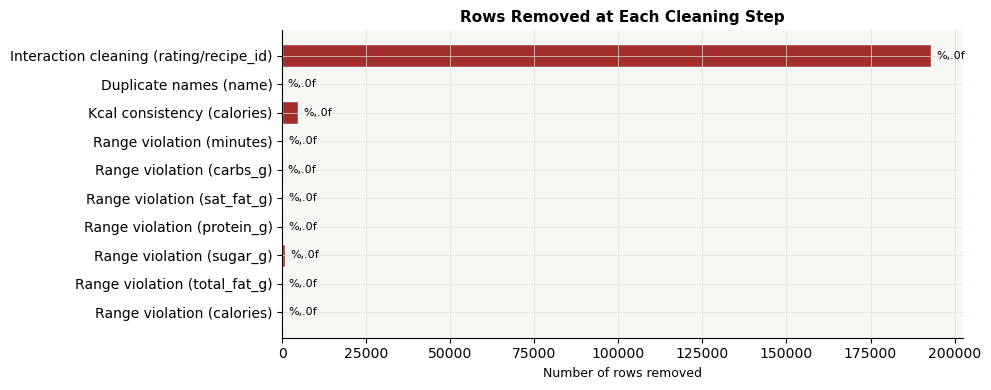

In [22]:
# ── 4.8 Visualise cleaning log ───────────────────────────────────────────────
df_log_vis = df_log[df_log['Removed'] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 4))
colors_log = [C_BEFORE if r > 100 else C_FLAG for r in df_log_vis['Removed']]
bars = ax.barh(df_log_vis['Step'] + ' (' + df_log_vis['Column'] + ')',
                df_log_vis['Removed'], color=colors_log, edgecolor='white')
ax.set_xlabel('Number of rows removed')
ax.set_title('Rows Removed at Each Cleaning Step', fontweight='bold')
ax.bar_label(bars, fmt='%,.0f', padding=4, fontsize=8)
plt.tight_layout()
plt.savefig('plots/eda_05_cleaning_log.png', dpi=120, bbox_inches='tight')
plt.show()


In [23]:
# ── 4.9 Save clean datasets ───────────────────────────────────────────────────
df_clean = df.drop(columns=['expected_kcal','kcal_error','tags_list'],
                    errors='ignore')
df_clean.to_csv('data/recipes_clean.csv', index=False)
df_inter.to_csv('data/interactions_clean.csv', index=False)
print(f'Saved data/recipes_clean.csv        ({len(df_clean):,} rows)')
print(f'Saved data/interactions_clean.csv   ({len(df_inter):,} rows)')


Saved data/recipes_clean.csv        (15,568 rows)
Saved data/interactions_clean.csv   (411,259 rows)


---
## Section 5 — EDA After Cleaning

Same visualisations as Section 3, now showing the cleaned data.
The side-by-side comparisons make the improvement explicit.


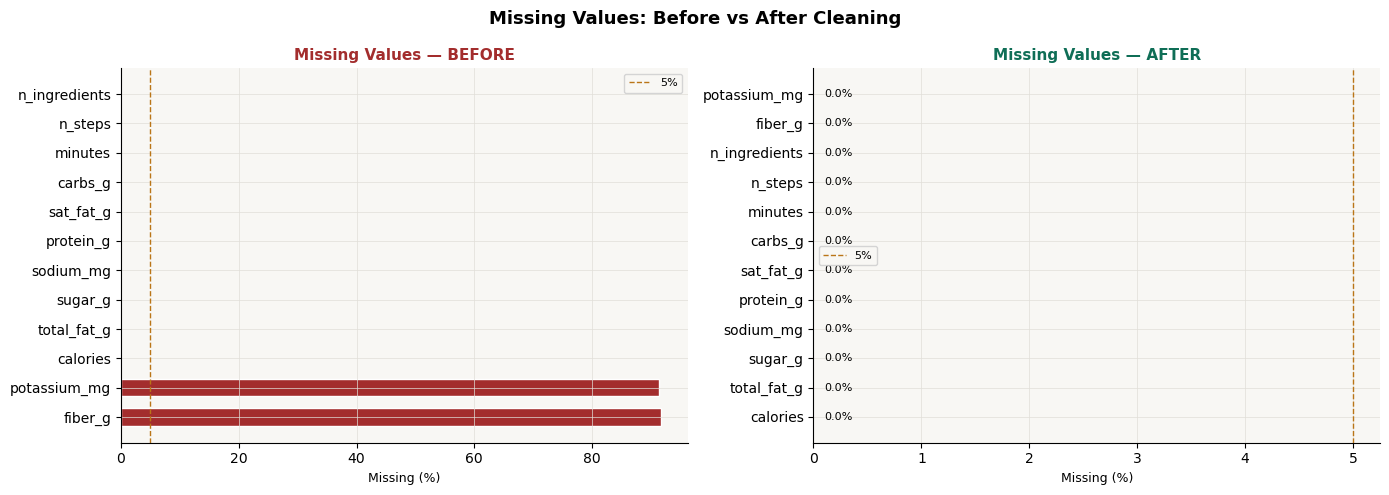

In [24]:
# ── 5.1 Missing values AFTER ─────────────────────────────────────────────────
miss_after = df[check_cols].isna().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
colors_b = [C_BEFORE if v > 0.05 else C_AFTER for v in miss_before]
axes[0].barh(miss_before.index, miss_before.values * 100,
              color=colors_b, edgecolor='white', height=0.6)
axes[0].axvline(5, color=C_FLAG, linestyle='--', linewidth=1, label='5%')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missing Values — BEFORE', fontweight='bold', color=C_BEFORE)
axes[0].legend(fontsize=8)

# After
colors_a = [C_BEFORE if v > 0.05 else C_AFTER for v in miss_after]
axes[1].barh(miss_after.index, miss_after.values * 100,
              color=colors_a, edgecolor='white', height=0.6)
axes[1].axvline(5, color=C_FLAG, linestyle='--', linewidth=1, label='5%')
axes[1].set_xlabel('Missing (%)')
axes[1].set_title('Missing Values — AFTER', fontweight='bold', color=C_AFTER)
axes[1].legend(fontsize=8)
for i, v in enumerate(miss_after.values):
    axes[1].text(max(v*100+0.1, 0.1), i, f'{v:.1%}', va='center', fontsize=8)

plt.suptitle('Missing Values: Before vs After Cleaning',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eda_06_after_missing.png', dpi=120, bbox_inches='tight')
plt.show()


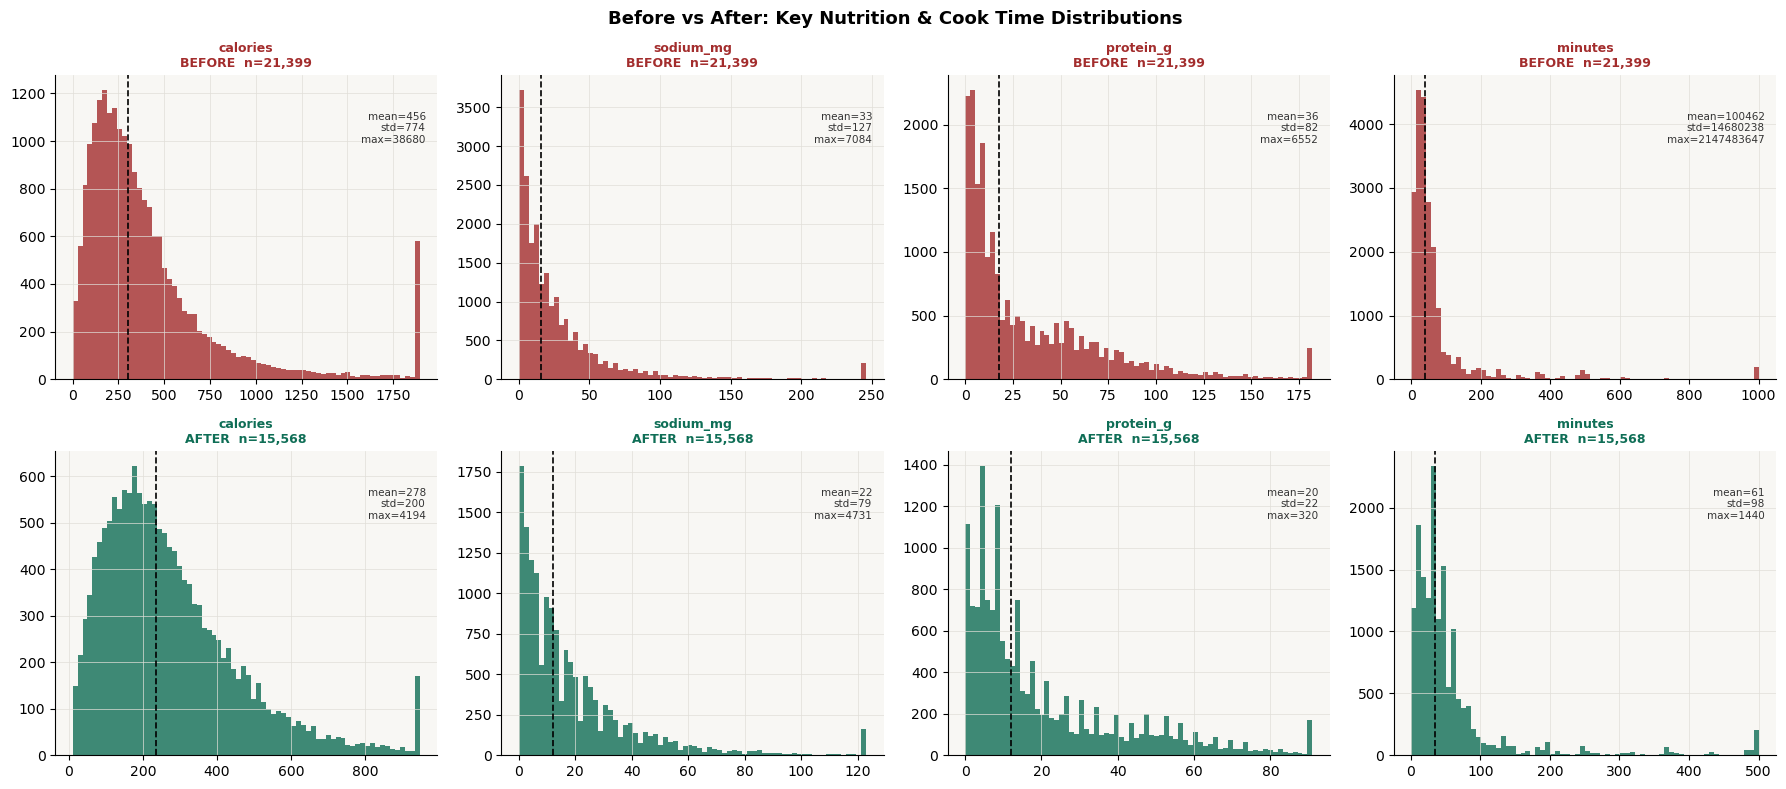

In [25]:
# ── 5.2 Side-by-side distributions ──────────────────────────────────────────
compare_cols = ['calories','sodium_mg','protein_g','minutes']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(compare_cols):
    raw_d   = df_recipes_raw[col].dropna()
    clean_d = df[col].dropna()
    clip_hi = clean_d.quantile(0.99)

    ax_b = axes[0, i]
    ax_a = axes[1, i]

    ax_b.hist(raw_d.clip(upper=clip_hi * 2), bins=70,
               color=C_BEFORE, alpha=0.8, edgecolor='none')
    ax_b.set_title(f'{col}\nBEFORE  n={len(raw_d):,}',
                    fontweight='bold', color=C_BEFORE, fontsize=9)
    ax_b.axvline(raw_d.median(), color='black', linewidth=1.2, linestyle='--')
    ax_b.text(0.97, 0.88,
               f'mean={raw_d.mean():.0f}\nstd={raw_d.std():.0f}\nmax={raw_d.max():.0f}',
               transform=ax_b.transAxes, ha='right', va='top',
               fontsize=7.5, color='#333')

    ax_a.hist(clean_d.clip(upper=clip_hi), bins=70,
               color=C_AFTER, alpha=0.8, edgecolor='none')
    ax_a.set_title(f'{col}\nAFTER  n={len(clean_d):,}',
                    fontweight='bold', color=C_AFTER, fontsize=9)
    ax_a.axvline(clean_d.median(), color='black', linewidth=1.2, linestyle='--')
    ax_a.text(0.97, 0.88,
               f'mean={clean_d.mean():.0f}\nstd={clean_d.std():.0f}\nmax={clean_d.max():.0f}',
               transform=ax_a.transAxes, ha='right', va='top',
               fontsize=7.5, color='#333')

plt.suptitle('Before vs After: Key Nutrition & Cook Time Distributions',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eda_07_before_after_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


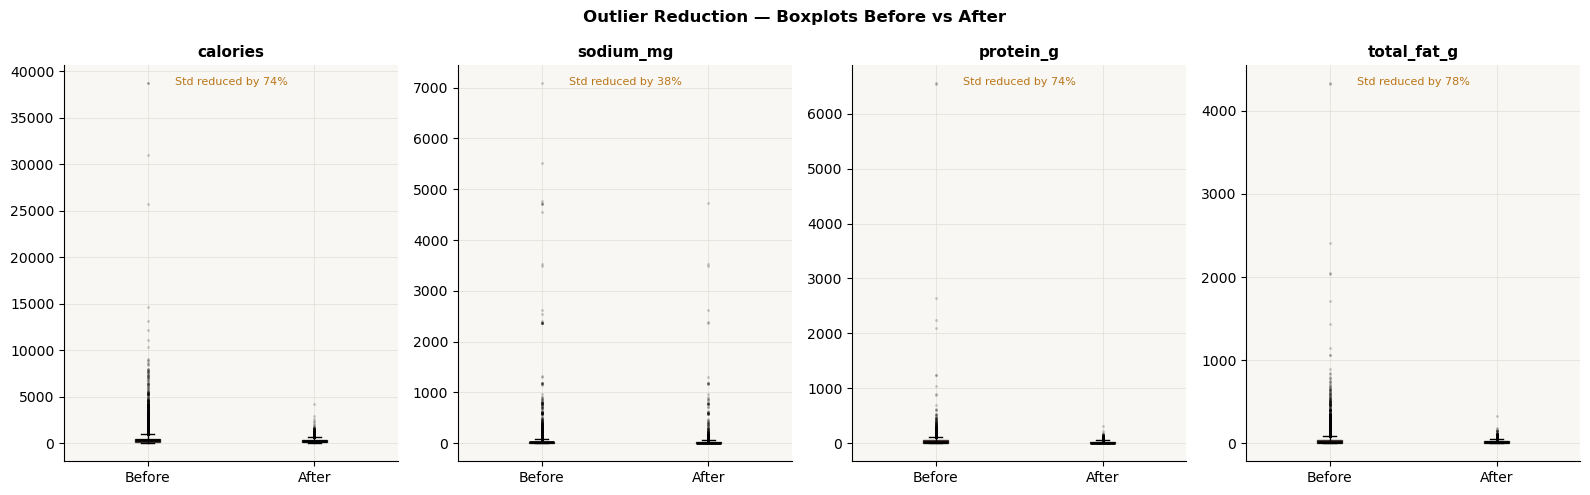

In [26]:
# ── 5.3 Boxplots before vs after ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, ['calories','sodium_mg','protein_g','total_fat_g']):
    raw_d   = df_recipes_raw[col].dropna()
    clean_d = df[col].dropna()

    bp = ax.boxplot(
        [raw_d, clean_d], labels=['Before','After'],
        patch_artist=True, notch=False,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='.', markersize=2, alpha=0.2)
    )
    bp['boxes'][0].set_facecolor(C_BEFORE); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(C_AFTER);  bp['boxes'][1].set_alpha(0.7)

    ax.set_title(col, fontweight='bold')
    pct_reduction = (raw_d.std() - clean_d.std()) / raw_d.std() * 100
    ax.text(0.5, 0.97, f'Std reduced by {pct_reduction:.0f}%',
             transform=ax.transAxes, ha='center', va='top',
             fontsize=8, color=C_FLAG)

plt.suptitle('Outlier Reduction — Boxplots Before vs After',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eda_08_boxplots_before_after.png', dpi=120, bbox_inches='tight')
plt.show()


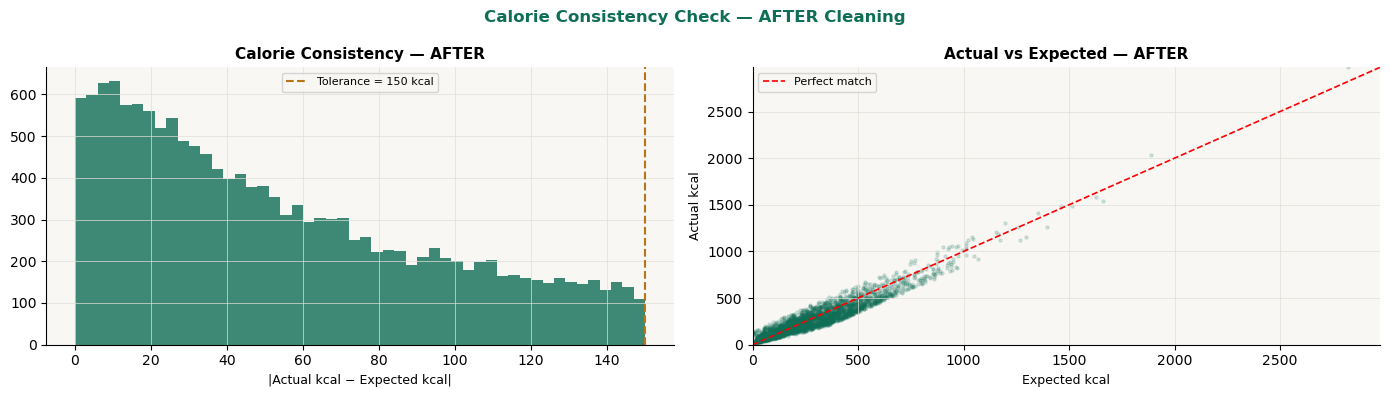

In [27]:
# ── 5.4 Calorie consistency AFTER ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

err_after = df['kcal_error']
axes[0].hist(err_after.clip(upper=200), bins=50, color=C_AFTER,
              alpha=0.8, edgecolor='none')
axes[0].axvline(150, color=C_FLAG, linestyle='--', linewidth=1.5,
                 label='Tolerance = 150 kcal')
axes[0].set_xlabel('|Actual kcal − Expected kcal|')
axes[0].set_title('Calorie Consistency — AFTER', fontweight='bold')
axes[0].legend(fontsize=8)

sample_clean = df.sample(n=min(3000, len(df)), random_state=42)
axes[1].scatter(sample_clean['expected_kcal'], sample_clean['calories'],
                 alpha=0.15, s=5, color=C_AFTER)
max_v = min(sample_clean[['calories','expected_kcal']].max().max(), 3000)
axes[1].plot([0, max_v], [0, max_v], 'r--', linewidth=1.2, label='Perfect match')
axes[1].set_xlabel('Expected kcal')
axes[1].set_ylabel('Actual kcal')
axes[1].set_title('Actual vs Expected — AFTER', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, max_v)
axes[1].set_ylim(0, max_v)

plt.suptitle('Calorie Consistency Check — AFTER Cleaning',
              fontsize=12, fontweight='bold', color=C_AFTER)
plt.tight_layout()
plt.savefig('plots/eda_09_after_consistency.png', dpi=120, bbox_inches='tight')
plt.show()


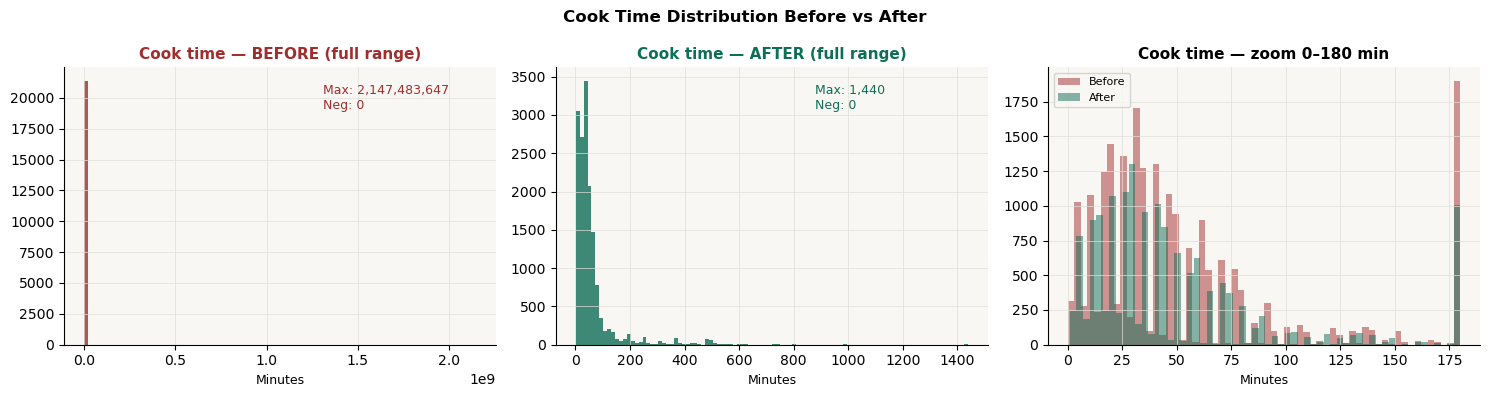

In [28]:
# ── 5.5 Cook time zoom ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

raw_time   = df_recipes_raw['minutes'].dropna()
clean_time = df['minutes'].dropna()

axes[0].hist(raw_time, bins=100, color=C_BEFORE, alpha=0.8, edgecolor='none')
axes[0].set_title('Cook time — BEFORE (full range)', fontweight='bold', color=C_BEFORE)
axes[0].set_xlabel('Minutes')
axes[0].text(0.6, 0.85,
              f'Max: {raw_time.max():,.0f}\nNeg: {(raw_time<0).sum()}',
              transform=axes[0].transAxes, fontsize=9, color=C_BEFORE)

axes[1].hist(clean_time, bins=100, color=C_AFTER, alpha=0.8, edgecolor='none')
axes[1].set_title('Cook time — AFTER (full range)', fontweight='bold', color=C_AFTER)
axes[1].set_xlabel('Minutes')
axes[1].text(0.6, 0.85,
              f'Max: {clean_time.max():,.0f}\nNeg: 0',
              transform=axes[1].transAxes, fontsize=9, color=C_AFTER)

# Zoom 0-180 min overlay
axes[2].hist(raw_time.clip(0, 180),   bins=60, color=C_BEFORE,
              alpha=0.5, label='Before', edgecolor='none')
axes[2].hist(clean_time.clip(0, 180), bins=60, color=C_AFTER,
              alpha=0.5, label='After',  edgecolor='none')
axes[2].set_title('Cook time — zoom 0–180 min', fontweight='bold')
axes[2].set_xlabel('Minutes')
axes[2].legend(fontsize=8)

plt.suptitle('Cook Time Distribution Before vs After',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eda_10_cooktime_before_after.png', dpi=120, bbox_inches='tight')
plt.show()


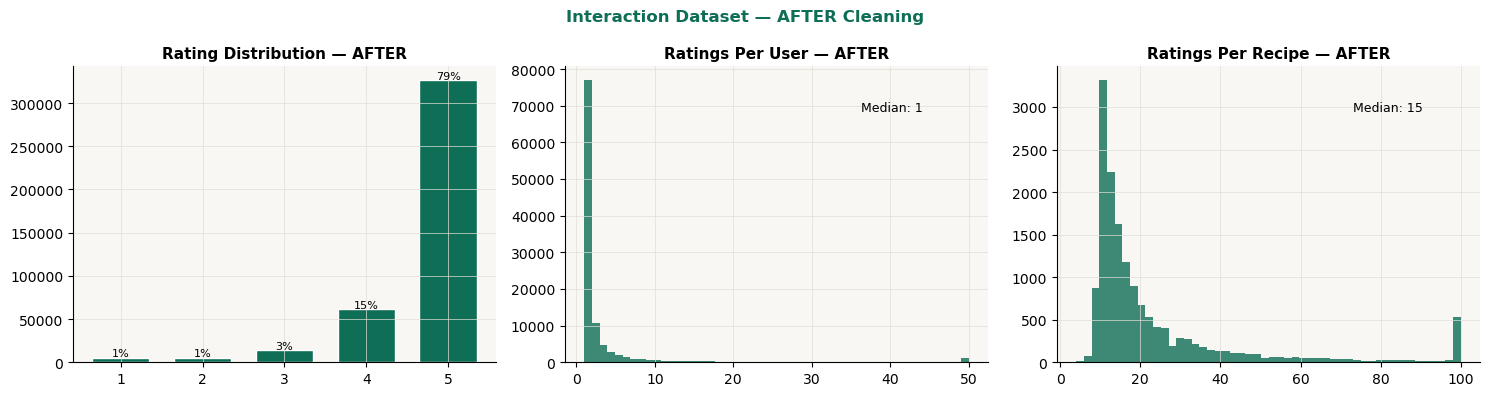

In [29]:
# ── 5.6 Interaction dataset AFTER ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

r_after = df_inter['rating'].value_counts().sort_index()
axes[0].bar(r_after.index, r_after.values, color=C_AFTER, edgecolor='white', width=0.7)
axes[0].set_title('Rating Distribution — AFTER', fontweight='bold')
for k, v in r_after.items():
    axes[0].text(k, v + 2000, f'{v/len(df_inter):.0%}', ha='center', fontsize=8)

rpu_after = df_inter.groupby('user_id').size()
axes[1].hist(rpu_after.clip(upper=50), bins=50, color=C_AFTER, alpha=0.8, edgecolor='none')
axes[1].set_title('Ratings Per User — AFTER', fontweight='bold')
axes[1].text(0.7, 0.85, f'Median: {rpu_after.median():.0f}',
              transform=axes[1].transAxes, fontsize=9)

rpr_after = df_inter.groupby('recipe_id').size()
axes[2].hist(rpr_after.clip(upper=100), bins=50, color=C_AFTER, alpha=0.8, edgecolor='none')
axes[2].set_title('Ratings Per Recipe — AFTER', fontweight='bold')
axes[2].text(0.7, 0.85, f'Median: {rpr_after.median():.0f}',
              transform=axes[2].transAxes, fontsize=9)

plt.suptitle('Interaction Dataset — AFTER Cleaning',
              fontsize=12, fontweight='bold', color=C_AFTER)
plt.tight_layout()
plt.savefig('plots/eda_11_after_interactions.png', dpi=120, bbox_inches='tight')
plt.show()


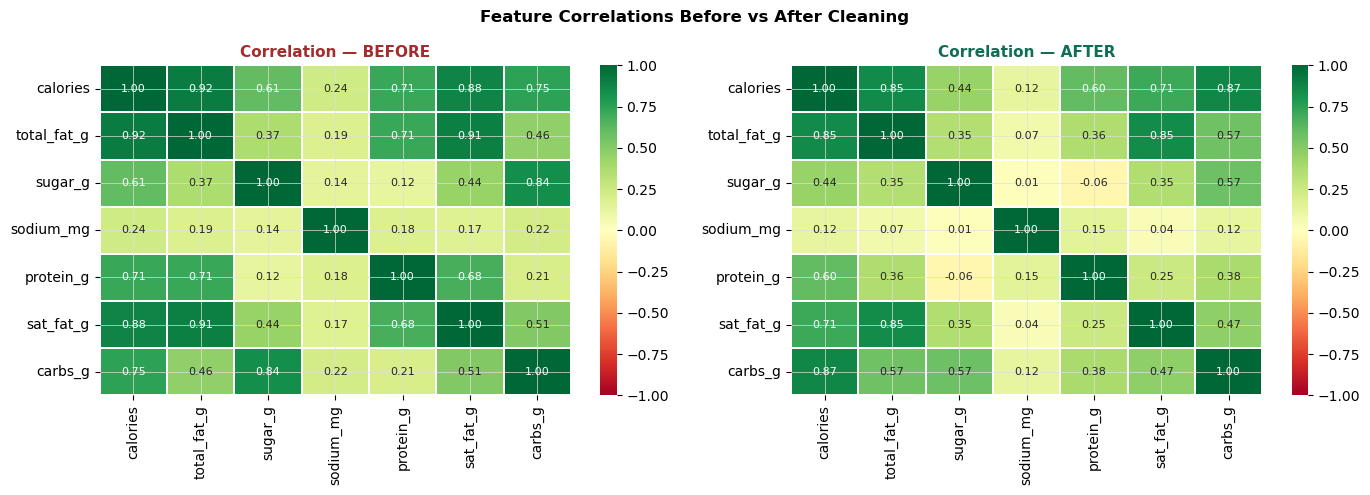

In [30]:
# ── 5.7 Correlation heatmap AFTER ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_cols = ['calories','total_fat_g','sugar_g','sodium_mg','protein_g','sat_fat_g','carbs_g']
corr_b = df_recipes_raw[corr_cols].corr()
corr_a = df[corr_cols].corr()

sns.heatmap(corr_b, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
             ax=axes[0], linewidths=0.3, annot_kws={'size':8}, vmin=-1, vmax=1)
axes[0].set_title('Correlation — BEFORE', fontweight='bold', color=C_BEFORE)

sns.heatmap(corr_a, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
             ax=axes[1], linewidths=0.3, annot_kws={'size':8}, vmin=-1, vmax=1)
axes[1].set_title('Correlation — AFTER', fontweight='bold', color=C_AFTER)

plt.suptitle('Feature Correlations Before vs After Cleaning',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eda_12_correlations.png', dpi=120, bbox_inches='tight')
plt.show()


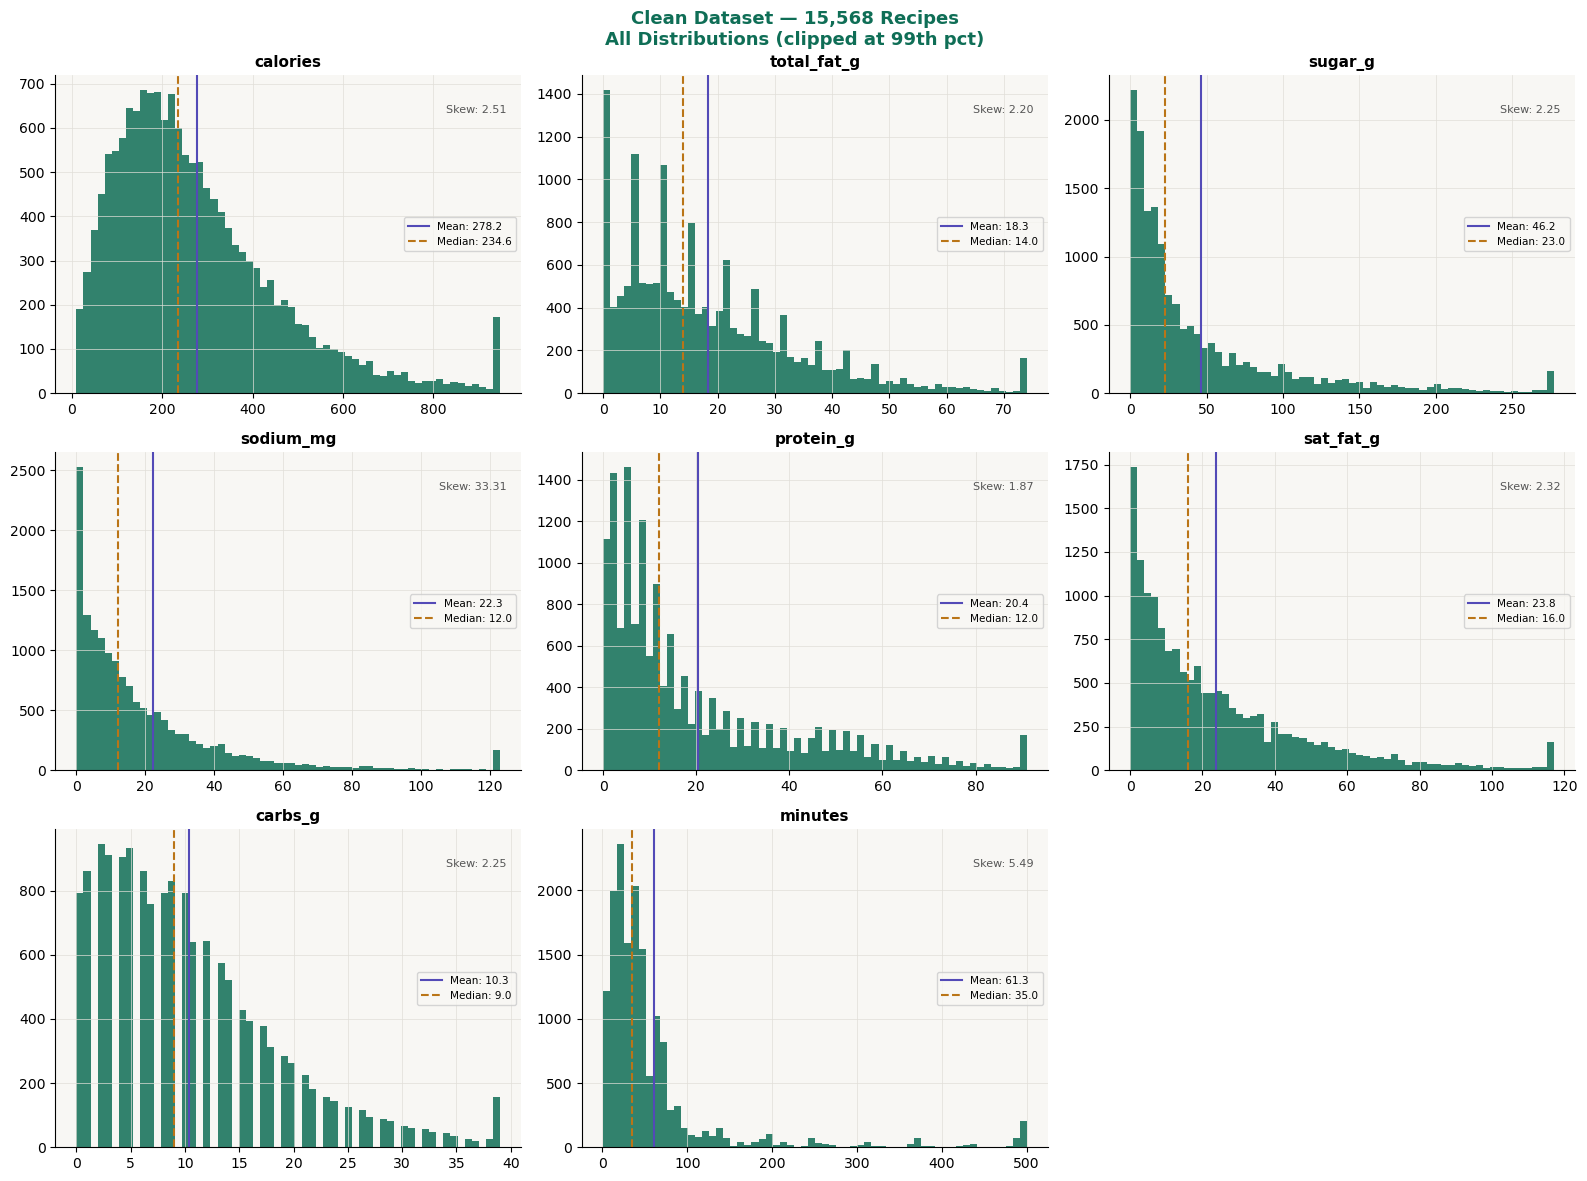

In [31]:
# ── 5.8 Final clean distributions — full EDA ─────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

final_cols = NUTRITION_COLS + ['minutes']
for ax, col in zip(axes, final_cols):
    data = df[col].dropna()
    clipped = data.clip(upper=data.quantile(0.99))
    ax.hist(clipped, bins=60, color=C_AFTER, alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(),   color=C_PURPLE, linewidth=1.5, linestyle='-',
               label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color=C_FLAG,   linewidth=1.5, linestyle='--',
               label=f'Median: {data.median():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7.5)
    # Skewness
    sk = stats.skew(data.dropna())
    ax.text(0.97, 0.88, f'Skew: {sk:.2f}',
             transform=ax.transAxes, ha='right', fontsize=8, color='#555')

for ax in axes[len(final_cols):]:
    ax.set_visible(False)

plt.suptitle(f'Clean Dataset — {len(df):,} Recipes\nAll Distributions (clipped at 99th pct)',
              fontsize=13, fontweight='bold', color=C_AFTER)
plt.tight_layout()
plt.savefig('plots/eda_13_final_clean_all.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 6 — Data Annotation
**Work Package: Data Annotation**

We assign health labels to recipes using two layers:
1. **Rule-based** — deterministic rules from clinical guidelines (covers all recipes)
2. **AI-assisted** — Claude API annotations for ambiguous cases (covers a sample)


In [ ]:
# ── Health label rules ────────────────────────────────────────────────────────
LABEL_COLS = ['diabetic_ok','low_sodium','low_calorie','high_protein',
               'low_fat','high_fiber','heart_healthy','vegetarian',
               'vegan','gluten_free','dairy_free']

VEGETARIAN_TAGS = {'vegetarian','vegan'}
VEGAN_TAGS      = {'vegan'}
GF_TAGS         = {'gluten-free','gluten_free'}
DAIRY_FREE_TAGS = {'dairy-free','dairy_free','non-dairy'}

def annotate_rule_based(row) -> dict:
    r    = row.to_dict()
    tags = set(r.get('tags_list', []) or [])
    def g(col): return float(r.get(col) or 0)
    return {
        'diabetic_ok':  int(g('carbs_g')     <= 45  and g('sugar_g')    <= 10),
        'low_sodium':   int(g('sodium_mg')   <= 400),
        'low_calorie':  int(g('calories')    <= 300),
        'high_protein': int(g('protein_g')   >= 25),
        'low_fat':      int(g('total_fat_g') <= 10),
        'high_fiber':   int(g('fiber_g')     >= 5),
        'heart_healthy':int(g('sat_fat_g')   <= 5   and g('sodium_mg')  <= 500),
        'vegetarian':   int(bool(tags & VEGETARIAN_TAGS) or
                            'vegetarian' in str(r.get('name','')).lower()),
        'vegan':        int(bool(tags & VEGAN_TAGS)),
        'gluten_free':  int(bool(tags & GF_TAGS)),
        'dairy_free':   int(bool(tags & DAIRY_FREE_TAGS)),
    }

print('Applying rule-based annotations to all recipes...')
label_rows = [annotate_rule_based(row) for _, row in df.iterrows()]
df_labels  = pd.DataFrame(label_rows, index=df.index)
df         = df.drop(columns=[c for c in LABEL_COLS if c in df.columns])
df         = pd.concat([df, df_labels], axis=1)

print('Label distribution:')
for col in LABEL_COLS:
    n   = df[col].sum()
    pct = df[col].mean()
    bar = '#' * int(pct * 35)
    print(f'  {col:<20} {bar:<37} {n:>6,}  ({pct:.1%})')


In [ ]:
# ── AI annotation using Claude API ───────────────────────────────────────────
# Set ANNOTATE_AI=True and provide your Anthropic API key to use AI annotation.
# AI annotations override rule-based ones for the sampled recipes.

ANNOTATE_AI     = False   # Set True to use Claude API
ANTHROPIC_KEY   = 'your-key-here'  # from console.anthropic.com
AI_SAMPLE_SIZE  = 500

AI_SYSTEM = '''You are a clinical dietitian annotating recipes.
Given nutritional values and recipe name, return ONLY a JSON object with
these keys as 0 or 1: diabetic_ok, low_sodium, low_calorie, high_protein,
low_fat, high_fiber, heart_healthy, vegetarian, vegan, gluten_free, dairy_free.
Rules: diabetic_ok: carbs<=45g AND sugar<=10g. low_sodium: sodium<=400mg.
low_calorie: calories<=300. high_protein: protein>=25g. low_fat: fat<=10g.
high_fiber: fiber>=5g. heart_healthy: sat_fat<=5g AND sodium<=500mg.
vegetarian/vegan/gluten_free/dairy_free: infer from recipe name and tags.
Return ONLY JSON, no explanation.'''

def ai_annotate_one(row, client):
    import anthropic
    prompt = (f"Recipe: {row['name']}\n"
               f"Calories: {row.get('calories','?')}  Protein: {row.get('protein_g','?')}g  "
               f"Carbs: {row.get('carbs_g','?')}g  Fat: {row.get('total_fat_g','?')}g  "
               f"Sodium: {row.get('sodium_mg','?')}mg  Sugar: {row.get('sugar_g','?')}g  "
               f"Fiber: {row.get('fiber_g','?')}g\n"
               f"Tags: {row.get('tags_list',[])}")
    try:
        resp = client.messages.create(
            model='claude-sonnet-4-6', max_tokens=200,
            system=AI_SYSTEM,
            messages=[{'role':'user','content':prompt}]
        )
        return {k: int(v) for k, v in json.loads(resp.content[0].text).items()
                if k in LABEL_COLS}
    except:
        return {}


if ANNOTATE_AI:
    import anthropic
    client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
    sample = df.sample(n=min(AI_SAMPLE_SIZE, len(df)), random_state=42)
    ai_rows = []
    for i, (_, row) in enumerate(sample.iterrows()):
        if i % 100 == 0: print(f'  AI annotating {i}/{len(sample)}')
        labels = ai_annotate_one(row, client)
        labels['recipe_id'] = row['id']
        ai_rows.append(labels)
        time.sleep(0.1)
    df_ai = pd.DataFrame(ai_rows)
    df_ai.to_csv('data/ai_annotations.csv', index=False)
    # Merge AI labels (override rule-based for annotated recipes)
    for col in LABEL_COLS:
        if col in df_ai.columns:
            mask = df['id'].isin(df_ai['recipe_id'])
            mapping = df_ai.set_index('recipe_id')[col]
            df.loc[mask, col] = df.loc[mask, 'id'].map(mapping).fillna(df.loc[mask, col])
    print(f'AI annotations applied for {len(df_ai)} recipes')
elif os.path.exists('data/ai_annotations.csv'):
    df_ai = pd.read_csv('data/ai_annotations.csv')
    for col in LABEL_COLS:
        if col in df_ai.columns:
            mask = df['id'].isin(df_ai['recipe_id'])
            mapping = df_ai.set_index('recipe_id')[col]
            df.loc[mask, col] = df.loc[mask, 'id'].map(mapping).fillna(df.loc[mask, col])
    print(f'Loaded AI annotations: {len(df_ai)} records merged')
else:
    print('Using rule-based annotations only (set ANNOTATE_AI=True for Claude API)')


In [ ]:
# ── Label distribution visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_freq = df[LABEL_COLS].mean().sort_values(ascending=True)
colors_lbl = [C_AFTER if v > 0.1 else C_FLAG for v in label_freq.values]
bars = axes[0].barh(label_freq.index, label_freq.values * 100,
                     color=colors_lbl, edgecolor='white')
axes[0].set_xlabel('% of recipes with label')
axes[0].set_title('Health Label Frequency', fontweight='bold')
axes[0].bar_label(bars, fmt='%.1f%%', padding=4, fontsize=8)

corr_lbl = df[LABEL_COLS].corr()
sns.heatmap(corr_lbl, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
             ax=axes[1], linewidths=0.3, annot_kws={'size':7}, vmin=-1, vmax=1)
axes[1].set_title('Label Co-occurrence Correlation', fontweight='bold')

plt.suptitle('Health Label Analysis after Annotation',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eda_14_label_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 7 — Vector Embeddings
**Work Package: Vector Embeddings**

Each recipe → normalised nutrition vector + binary health label vector.
$$\mathbf{r}_i = \left[\frac{cal}{2000},\ \frac{prot}{150},\ \frac{carbs}{300},\ \frac{fat}{100},\ \frac{sodium}{5000},\ \frac{sugar}{200},\ label_1,\ \ldots\right]$$


In [ ]:
# ── Build recipe matrix R ────────────────────────────────────────────────────
FEATURE_MAX = dict(calories=2000, protein_g=150, carbs_g=300,
                    total_fat_g=100, sodium_mg=5000, sugar_g=200)
NUMERIC_FEATS = list(FEATURE_MAX.keys())
ALL_FEATS     = NUMERIC_FEATS + LABEL_COLS

def build_R(df_):
    nut = df_[NUMERIC_FEATS].copy()
    for col, mx in FEATURE_MAX.items():
        nut[col] = (nut[col].fillna(0) / mx).clip(0, 1)
    lbl = df_[LABEL_COLS].fillna(0).astype(float)
    feat_df = pd.concat([nut, lbl], axis=1)
    return feat_df.values, list(feat_df.columns)

R, FEAT_NAMES = build_R(df)
RECIPE_IDS    = list(df['id'])
RID2IDX       = {rid: i for i, rid in enumerate(RECIPE_IDS)}
np.save('models/recipe_matrix.npy', R)

print(f'Recipe matrix R: {R.shape}  ({R.shape[0]} recipes x {R.shape[1]} features)')
print(f'Features: {FEAT_NAMES}')


In [ ]:
# ── User health profile vectors ───────────────────────────────────────────────
def user_vec(cal, prot, carbs, fat, sodium, sugar,
              diabetic=False, low_sodium=False, low_cal=False,
              high_prot=False, low_fat=False, high_fiber=False,
              heart_healthy=False, vegetarian=False,
              vegan=False, gf=False, df_free=False):
    n = np.array([cal/2000, prot/150, carbs/300, fat/100, sodium/5000, sugar/200])
    l = np.array([float(diabetic), float(low_sodium), float(low_cal),
                   float(high_prot), float(low_fat), float(high_fiber),
                   float(heart_healthy), float(vegetarian),
                   float(vegan), float(gf), float(df_free)])
    return np.concatenate([np.clip(n, 0, 1), l])

DEMO_USERS = {
    'alice': {'vec': user_vec(400,40,45,30,600,10, diabetic=True, high_prot=True),
               'profile': 'Type 2 diabetic, high-protein goal'},
    'bob':   {'vec': user_vec(700,35,200,60,2000,80),
               'profile': 'Healthy, no restrictions'},
    'carol': {'vec': user_vec(400,20,200,20,400,40, vegetarian=True, vegan=True,
                               heart_healthy=True, low_sodium=True),
               'profile': 'Vegan, heart-healthy, low-sodium'},
    'david': {'vec': user_vec(500,30,150,40,300,40, low_sodium=True, heart_healthy=True),
               'profile': 'Hypertensive, low-sodium'},
    'emma':  {'vec': user_vec(300,25,100,10,800,20, low_cal=True, low_fat=True),
               'profile': 'Weight-loss, low-calorie low-fat'},
}
print('User profiles ready.')
for name, info in DEMO_USERS.items():
    print(f'  {name:<8} {info["profile"]}')


In [ ]:
# ── Embedding space visualisation (PCA 2D) ────────────────────────────────────
pca  = PCA(n_components=2, random_state=42)
R_2d = pca.fit_transform(R)

fig, ax = plt.subplots(figsize=(12, 7))

# Colour by diabetic_ok
diab = df['diabetic_ok'].values == 1
ax.scatter(R_2d[~diab, 0], R_2d[~diab, 1], c='#D3D1C7', alpha=0.25, s=6,
            label=f'Not diabetic-ok ({(~diab).sum():,})')
ax.scatter(R_2d[diab, 0],  R_2d[diab, 1],  c=C_AFTER,  alpha=0.55, s=7,
            label=f'Diabetic-ok ({diab.sum():,})')

# User vectors
U_2d = pca.transform(np.array([u['vec'] for u in DEMO_USERS.values()]))
for i, (uname, info) in enumerate(DEMO_USERS.items()):
    ax.scatter(U_2d[i,0], U_2d[i,1], c=C_BEFORE, s=200, marker='*', zorder=5)
    ax.annotate(uname, (U_2d[i,0], U_2d[i,1]),
                xytext=(7,5), textcoords='offset points',
                fontsize=9, fontweight='bold', color=C_BEFORE)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Recipe Embedding Space — PCA 2D\n'
              'Green = diabetic-ok recipes  |  Red stars = user health profiles',
              fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/eda_15_embedding_space.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 8 — Content-Based Filtering
**Work Package: Recommender System**
$$\text{score}(u,r) = \cos(\mathbf{u},\mathbf{r}) = \frac{\mathbf{u}\cdot\mathbf{r}}{\|\mathbf{u}\|\cdot\|\mathbf{r}\|}$$


In [ ]:
def cb_scores(uvec):
    return cosine_similarity(uvec.reshape(1,-1), R).flatten()

def cb_recommend(user_name, k=10):
    sc = cb_scores(DEMO_USERS[user_name]['vec'])
    res = df[['id','name','calories','protein_g','carbs_g',
               'total_fat_g','sodium_mg'] + LABEL_COLS].copy()
    res['cb_score'] = sc
    return res.nlargest(k, 'cb_score').reset_index(drop=True)

print('=== Content-Based Top-10 for Alice (diabetic, high-protein) ===')
alice_cb = cb_recommend('alice', k=10)
print(alice_cb[['name','calories','protein_g','carbs_g','sodium_mg',
                 'diabetic_ok','cb_score']].to_string(index=False))


In [ ]:
# Score matrix heatmap
S_cb = np.array([cb_scores(info['vec']) for info in DEMO_USERS.values()])
fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(S_cb, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_yticks(range(len(DEMO_USERS)))
ax.set_yticklabels([f'{n}  ({DEMO_USERS[n]["profile"][:35]})'
                     for n in DEMO_USERS])
ax.set_xlabel('Recipe index')
ax.set_title('Content-Based Score Matrix  S[user, recipe]', fontweight='bold')
plt.colorbar(im, ax=ax, label='Cosine similarity')
plt.tight_layout()
plt.savefig('plots/rec_01_score_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 9 — Collaborative Filtering (SVD)
**Work Package: Recommender System**
$$R \approx U \times V^T \quad\quad \mathcal{L} = \sum_{(u,r)}(R_{ur} - \mathbf{u}_u\cdot\mathbf{v}_r)^2 + \lambda(\|U\|^2+\|V\|^2)$$


In [ ]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as svd_split

# Map original IDs to integer indices
unique_users   = df_inter['user_id'].unique()
unique_recipes = df_inter['recipe_id'].unique()
u2i = {u:i for i,u in enumerate(unique_users)}
r2i = {r:i for i,r in enumerate(unique_recipes)}
i2r = {i:r for r,i in r2i.items()}

df_inter_m = df_inter.copy()
df_inter_m['uid'] = df_inter_m['user_id'].map(u2i)
df_inter_m['rid'] = df_inter_m['recipe_id'].map(r2i)

reader   = Reader(rating_scale=(1,5))
data_svd = Dataset.load_from_df(df_inter_m[['uid','rid','rating']], reader)
trainset, testset = svd_split(data_svd, test_size=0.2, random_state=42)

print('Training SVD...')
svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.1, random_state=42)
svd.fit(trainset)
preds = svd.test(testset)
print(f'RMSE: {accuracy.rmse(preds, verbose=False):.4f}')
print(f'MAE:  {accuracy.mae(preds,  verbose=False):.4f}')

with open('models/svd_model.pkl','wb') as f:
    pickle.dump(svd, f)
print('Model saved.')


In [ ]:
# Training loss simulation plot (Surprise doesn't expose per-epoch loss,
# so we train multiple models with increasing epochs to show convergence)
rmse_curve = []
for ep in [2,4,6,8,10,15,20]:
    m = SVD(n_factors=50, n_epochs=ep, lr_all=0.005, reg_all=0.1, random_state=42)
    m.fit(trainset)
    pr = m.test(testset)
    rmse_curve.append((ep, accuracy.rmse(pr, verbose=False)))

epochs_x, rmse_y = zip(*rmse_curve)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(epochs_x, rmse_y, marker='o', color=C_PURPLE, linewidth=2, markersize=6)
ax.set_xlabel('Training epochs')
ax.set_ylabel('RMSE on test set')
ax.set_title('SVD Convergence — RMSE vs Epochs', fontweight='bold')
ax.annotate(f'Final RMSE: {rmse_y[-1]:.4f}',
             xy=(epochs_x[-1], rmse_y[-1]),
             xytext=(-60, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color=C_BEFORE),
             color=C_BEFORE, fontsize=9)
plt.tight_layout()
plt.savefig('plots/rec_02_svd_convergence.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 10 — Hybrid Recommender + Health Filter
**Work Package: Recommender System**
$$\text{final}(u,r) = \alpha \cdot \text{cb}(u,r) + (1-\alpha)\cdot\text{cf}(u,r)$$


In [ ]:
HEALTH_CONSTRAINTS = {
    'alice': {'diabetic':True,  'hypertensive':False,'vegan':False,'gf':False},
    'bob':   {'diabetic':False, 'hypertensive':False,'vegan':False,'gf':False},
    'carol': {'diabetic':False, 'hypertensive':False,'vegan':True, 'gf':False},
    'david': {'diabetic':False, 'hypertensive':True, 'vegan':False,'gf':False},
    'emma':  {'diabetic':False, 'hypertensive':False,'vegan':False,'gf':False},
}

def hybrid_scores(user_name, uid_orig=None, alpha=0.6):
    cb = cb_scores(DEMO_USERS[user_name]['vec'])
    cb_n = (cb - cb.min()) / (cb.max() - cb.min() + 1e-9)
    if uid_orig is not None and uid_orig in u2i:
        ui   = u2i[uid_orig]
        cf_r = np.array([svd.predict(ui, r2i.get(rid,-1)).est
                          if rid in r2i else 3.0 for rid in RECIPE_IDS])
        cf_n = (cf_r - cf_r.min()) / (cf_r.max() - cf_r.min() + 1e-9)
    else:
        cf_n = cb_n; alpha = 1.0
    return alpha * cb_n + (1 - alpha) * cf_n

def health_filter(df_r, c):
    df_r = df_r.copy(); df_r['blocked'] = ''
    if c.get('diabetic'):
        m = (df_r['carbs_g']>45)|(df_r['sugar_g']>10)
        df_r.loc[m,'blocked'] += 'high-carb/sugar; '
    if c.get('hypertensive'):
        m = df_r['sodium_mg'] > 600
        df_r.loc[m,'blocked'] += 'high-sodium; '
    if c.get('vegan'):      df_r.loc[df_r['vegan']==0,   'blocked'] += 'not-vegan; '
    if c.get('gf'):         df_r.loc[df_r['gluten_free']==0,'blocked'] += 'has-gluten; '
    df_r['allowed'] = df_r['blocked'] == ''
    return df_r

def full_recommend(user_name, uid_orig=None, alpha=0.6, k=10):
    sc  = hybrid_scores(user_name, uid_orig, alpha)
    res = df[['id','name','calories','protein_g','carbs_g',
               'total_fat_g','sodium_mg','sugar_g'] + LABEL_COLS].copy()
    res['score'] = sc
    top200 = res.nlargest(200, 'score')
    filt   = health_filter(top200, HEALTH_CONSTRAINTS[user_name])
    return filt[filt['allowed']].head(k).reset_index(drop=True)


# ── Health filter visualisation for Alice ─────────────────────────────────────
sc_alice  = hybrid_scores('alice', alpha=0.6)
res_alice = df[['id','name','calories','protein_g','carbs_g',
                 'sodium_mg','sugar_g'] + LABEL_COLS].copy()
res_alice['score'] = sc_alice
top20 = res_alice.nlargest(20, 'score')
top20_filt = health_filter(top20, HEALTH_CONSTRAINTS['alice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_f = [C_BEFORE if not a else C_AFTER for a in top20_filt['allowed']]
axes[0].barh(top20_filt['name'], top20_filt['score'], color=colors_f)
axes[0].set_title('BEFORE filter (red = blocked)', fontweight='bold', color=C_BEFORE)
axes[0].invert_yaxis()

allowed = top20_filt[top20_filt['allowed']].head(10)
axes[1].barh(allowed['name'], allowed['score'], color=C_AFTER)
axes[1].set_title('AFTER filter (diabetic: carbs≤45g, sugar≤10g)',
                   fontweight='bold', color=C_AFTER)
axes[1].invert_yaxis()

plt.suptitle('Health Constraint Filter — Alice (Type 2 Diabetic)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/rec_03_health_filter.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop-5 recommendations per user:')
for uname in DEMO_USERS:
    recs = full_recommend(uname, k=3)
    print(f'  {uname:<8} → {list(recs["name"].values)}')


---
## Section 11 — Perturbation Analysis
**Work Package: Perturbation Analysis**
$$J(A,B) = \frac{|A\cap B|}{|A\cup B|}$$


In [ ]:
def jaccard(a,b): return len(a&b)/len(a|b) if a|b else 1.0

def get_topk(uvec, k=10):
    sc = cosine_similarity(uvec.reshape(1,-1), R).flatten()
    return set(np.array(RECIPE_IDS)[np.argsort(sc)[::-1][:k]])

SIGMA_LEVELS = [0.01, 0.03, 0.05, 0.10, 0.20]
FLAG_NAMES   = ['diabetic','low_sodium','low_calorie','high_protein']
N_TRIALS     = 50

perturb_rows = []
for uname, info in DEMO_USERS.items():
    base = info['vec']; base_top = get_topk(base)
    for sigma in SIGMA_LEVELS:
        jvals = []
        for _ in range(N_TRIALS):
            p = base.copy(); p[:6] += np.random.normal(0, sigma, 6)
            jvals.append(jaccard(base_top, get_topk(np.clip(p,0,1))))
        perturb_rows.append({'user':uname,
                              'perturbation':f'noise σ={sigma}',
                              'mean_J':np.mean(jvals),'std_J':np.std(jvals)})
    for fi, fname in enumerate(FLAG_NAMES):
        p = base.copy(); p[6+fi] = 1 - p[6+fi]
        j = jaccard(base_top, get_topk(p))
        perturb_rows.append({'user':uname,'perturbation':f'flip:{fname}',
                              'mean_J':j,'std_J':0})

df_perturb = pd.DataFrame(perturb_rows)

# Plot
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)
for ax, uname in zip(axes, DEMO_USERS):
    sub = df_perturb[df_perturb['user']==uname]
    colors_p = [C_AFTER if v>=0.7 else C_FLAG if v>=0.4 else C_BEFORE
                 for v in sub['mean_J']]
    ax.barh(sub['perturbation'], sub['mean_J'], color=colors_p, edgecolor='none')
    ax.axvline(0.7, color=C_AFTER,  linestyle='--', linewidth=1)
    ax.axvline(0.4, color=C_BEFORE, linestyle='--', linewidth=1)
    ax.set_xlim(0, 1.1)
    ax.set_title(uname, fontweight='bold')
    ax.set_xlabel('Jaccard')

plt.suptitle('Perturbation Robustness — All Users  (green≥0.7 robust, red<0.4 fragile)',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eval_01_perturbation.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 12 — Performance Evaluation
**Work Package: Performance Evaluation**

Two methods (required):
- **Method 1:** Holdout split 80/20 — Precision@k, Recall@k, F1@k
- **Method 2:** Leave-one-out — Hit@10


In [ ]:
def prec_at_k(rec,rel,k): hits=len(set(rec[:k])&rel); return hits/k if k else 0
def rec_at_k(rec,rel,k):  hits=len(set(rec[:k])&rel); return hits/len(rel) if rel else 0
def f1_at_k(p,r): return 2*p*r/(p+r) if p+r else 0

# Build relevance sets (ratings >= 4)
RELEV_THR   = 4
eval_users  = (df_inter.groupby('user_id').size()
               .pipe(lambda s: s[s>=5]).index[:400])
relev_sets  = {}
for uid in eval_users:
    liked = set(df_inter[(df_inter['user_id']==uid) &
                          (df_inter['rating']>=RELEV_THR)]['recipe_id'])
    if liked: relev_sets[uid] = liked

K_VALUES = [1,3,5,10,15,20]

print('Evaluating CF (SVD)...')
cf_rows = []
for k in K_VALUES:
    p_l,r_l,f_l = [],[],[]
    for uid in list(relev_sets)[:300]:
        if uid not in u2i: continue
        ui     = u2i[uid]
        seen   = set(df_inter[df_inter['user_id']==uid]['recipe_id'])
        unseen = [rid for rid in unique_recipes if rid not in seen and rid in r2i]
        if not unseen: continue
        preds  = sorted([(rid, svd.predict(ui, r2i[rid]).est)
                          for rid in unseen], key=lambda x:x[1], reverse=True)
        rec_ids= [p[0] for p in preds[:max(K_VALUES)]]
        rel    = relev_sets[uid]
        p      = prec_at_k(rec_ids, rel, k)
        r      = rec_at_k(rec_ids, rel, k)
        p_l.append(p); r_l.append(r); f_l.append(f1_at_k(p,r))
    cf_rows.append({'k':k,'method':'CF (SVD)',
                     'precision':np.mean(p_l),'recall':np.mean(r_l),'f1':np.mean(f_l)})

print('Evaluating CB (cosine)...')
cb_rows = []
for k in K_VALUES:
    p_l,r_l,f_l = [],[],[]
    for uid in list(relev_sets)[:200]:
        top_ids = df_inter[(df_inter['user_id']==uid) &
                            (df_inter['rating']>=4)]['recipe_id'].values[:5]
        vidx = [RID2IDX[rid] for rid in top_ids if rid in RID2IDX]
        if not vidx: continue
        uv  = R[vidx].mean(axis=0)
        sc  = cosine_similarity(uv.reshape(1,-1), R).flatten()
        rec_ids = [RECIPE_IDS[i] for i in np.argsort(sc)[::-1]]
        rel = relev_sets[uid]
        p   = prec_at_k(rec_ids, rel, k)
        r   = rec_at_k(rec_ids, rel, k)
        p_l.append(p); r_l.append(r); f_l.append(f1_at_k(p,r))
    cb_rows.append({'k':k,'method':'CB (cosine)',
                     'precision':np.mean(p_l),'recall':np.mean(r_l),'f1':np.mean(f_l)})

eval_all = pd.concat([pd.DataFrame(cf_rows), pd.DataFrame(cb_rows)])
print('\n=== Evaluation Results ===')
print(eval_all.pivot_table(index='k', columns='method',
      values=['precision','recall','f1']).round(4).to_string())


In [ ]:
# Evaluation curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_ev = {'CF (SVD)':C_PURPLE, 'CB (cosine)':C_AFTER}

for ax, metric in zip(axes, ['precision','recall','f1']):
    for method, color in colors_ev.items():
        sub = eval_all[eval_all['method']==method]
        ax.plot(sub['k'], sub[metric], marker='o', color=color,
                 linewidth=2, markersize=5, label=method)
    ax.set_xlabel('k')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()}@k', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Recommender Evaluation — Food.com Dataset',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eval_02_metrics_curves.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# Method 2: Leave-one-out
print('=== Method 2: Leave-One-Out Hit@10 ===')
hits = []
for uid in list(relev_sets)[:200]:
    if uid not in u2i: continue
    ui    = u2i[uid]
    ur    = df_inter[df_inter['user_id']==uid].sort_values('rating',ascending=False)
    if len(ur) < 2: continue
    held  = int(ur.iloc[0]['recipe_id'])
    if held not in r2i: continue
    unseen= [rid for rid in unique_recipes if rid!=held and rid in r2i]
    preds = sorted([(rid, svd.predict(ui,r2i[rid]).est) for rid in unseen],
                    key=lambda x:x[1], reverse=True)
    hits.append(int(held in {p[0] for p in preds[:10]}))

print(f'Hit@10: {np.mean(hits):.1%}  ({sum(hits)}/{len(hits)} users)')


---
## Section 13 — Hyperparameter Tuning (Optuna)
**Work Package: Hyperparameter Tuning**


In [ ]:
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE_USERS = list(relev_sets.keys())[:80]

def objective(trial):
    nf  = trial.suggest_int('n_factors', 10, 150)
    reg = trial.suggest_float('reg_all',  0.001, 1.0,  log=True)
    lr  = trial.suggest_float('lr_all',   0.001, 0.05, log=True)
    alp = trial.suggest_float('alpha',    0.0,   1.0)
    m   = SVD(n_factors=nf, reg_all=reg, lr_all=lr, n_epochs=10, random_state=42)
    m.fit(trainset)
    p_list = []
    for uid in TUNE_USERS:
        if uid not in u2i: continue
        ui   = u2i[uid]
        rel  = relev_sets.get(uid,set())
        if not rel: continue
        seen = set(df_inter[df_inter['user_id']==uid]['recipe_id'])
        unseen = [rid for rid in unique_recipes if rid not in seen and rid in r2i]
        if not unseen: continue
        cf_r = np.array([m.predict(ui,r2i[rid]).est for rid in unseen])
        cf_n = (cf_r-cf_r.min())/(cf_r.max()-cf_r.min()+1e-9)
        top_ids = df_inter[(df_inter['user_id']==uid)&(df_inter['rating']>=4)]['recipe_id'].values[:5]
        vidx    = [RID2IDX[r] for r in top_ids if r in RID2IDX]
        if not vidx: continue
        uv   = R[vidx].mean(0)
        ui_idx=[RID2IDX[r] for r in unseen if r in RID2IDX]
        if not ui_idx: continue
        cb_r = cosine_similarity(uv.reshape(1,-1), R[ui_idx]).flatten()
        cb_n = (cb_r-cb_r.min())/(cb_r.max()-cb_r.min()+1e-9)
        n    = min(len(cb_n),len(cf_n))
        final= alp*cb_n[:n]+(1-alp)*cf_n[:n]
        rids = [unseen[i] for i in np.argsort(final)[::-1][:10]]
        p_list.append(prec_at_k(rids,rel,10))
    return np.mean(p_list) if p_list else 0.0

print('Running Optuna (50 trials)...')
study = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

best = study.best_params
print(f'Best Precision@10: {study.best_value:.4f}')
for k,v in best.items(): print(f'  {k:<15} = {v}')


In [ ]:
# Hyperparameter importance plots
tdf = study.trials_dataframe()
params = ['params_n_factors','params_reg_all','params_lr_all','params_alpha']
labels = ['n_factors (k)','λ (reg)','lr','α (blend)']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, param, label in zip(axes, params, labels):
    if param not in tdf.columns: continue
    sc = ax.scatter(tdf[param], tdf['value'],
                     c=tdf['value'], cmap='RdYlGn', alpha=0.7, s=40)
    bv = best.get(param.replace('params_',''), None)
    if bv is not None:
        ax.axvline(bv, color='black', linestyle='--', linewidth=1.5,
                    label=f'best={bv:.4f}')
        ax.legend(fontsize=8)
    ax.set_xlabel(label)
    ax.set_ylabel('Precision@10')
    ax.set_title(f'Effect of {label}', fontweight='bold')
    plt.colorbar(sc, ax=ax)

plt.suptitle('Optuna Hyperparameter Search Results',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eval_03_hyperparams.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# Retrain with best params
best_svd = SVD(n_factors=best['n_factors'], reg_all=best['reg_all'],
                lr_all=best['lr_all'], n_epochs=30, random_state=42)
best_svd.fit(trainset)
bp = best_svd.test(testset)
print(f'Tuned RMSE: {accuracy.rmse(bp, verbose=False):.4f}')
print(f'Tuned MAE:  {accuracy.mae(bp,  verbose=False):.4f}')
with open('models/svd_best.pkl','wb') as f:
    pickle.dump({'model':best_svd,'params':best}, f)
print('Best model saved → models/svd_best.pkl')


---
## Section 14 — Experiment Logging (W&B)
**Work Package: Experiments Logging**


In [ ]:
WANDB_ENABLED = False  # Set True after: wandb login

if WANDB_ENABLED:
    import wandb
    for trial in study.trials:
        wandb.init(project='food-recommender-foodcom',
                    name=f'trial-{trial.number:03d}',
                    config=trial.params, reinit=True,
                    tags=['optuna','svd'])
        wandb.log({'precision_at_10': trial.value, **trial.params})
        wandb.finish()
    print(f'{len(study.trials)} trials logged to W&B')
else:
    print('W&B disabled. Set WANDB_ENABLED=True after: pip install wandb && wandb login')
    print(f'Would log {len(study.trials)} trials.')
    print(f'Best: precision@10={study.best_value:.4f}  params={best}')


---
## Section 15 — Streamlit Frontend
**Work Package: Frontend Application**

Run with: `streamlit run app.py`


In [ ]:
APP = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px

st.set_page_config(page_title="Food Recommender",page_icon="\U0001f957",layout="wide")

FEATURE_MAX=dict(calories=2000,protein_g=150,carbs_g=300,total_fat_g=100,sodium_mg=5000,sugar_g=200)
LABEL_COLS=["diabetic_ok","low_sodium","low_calorie","high_protein","low_fat","high_fiber",
             "heart_healthy","vegetarian","vegan","gluten_free","dairy_free"]

@st.cache_data
def load_data(): return pd.read_csv("data/recipes_clean.csv")

@st.cache_resource
def load_model():
    try:
        with open("models/svd_best.pkl","rb") as f: return pickle.load(f)
    except: return None

df=load_data()
NUM=[c for c in FEATURE_MAX]
nut=df[NUM].copy()
for c,mx in FEATURE_MAX.items(): nut[c]=nut[c].fillna(0)/mx
lbl=df[LABEL_COLS].fillna(0).astype(float)
R=pd.concat([nut,lbl],axis=1).values

st.title("\U0001f957 Health-Personalized Food Recommender")
st.caption(f"Food.com dataset  |  {len(df):,} recipes after cleaning")

c1,c2=st.columns([1,2])
with c1:
    st.subheader("Your health profile")
    cal  =st.slider("Target calories",200,900,500,50)
    prot =st.slider("Target protein (g)",5,80,30,5)
    carbs=st.slider("Max carbs (g)",10,300,150,10)
    fat  =st.slider("Max fat (g)",5,100,40,5)
    sod  =st.slider("Max sodium (mg)",100,3000,800,100)
    sug  =st.slider("Max sugar (g)",0,80,20,5)
    st.divider()
    diab =st.checkbox("Type 2 Diabetes  (carbs≤45g, sugar≤10g)")
    hyp  =st.checkbox("Hypertension  (sodium≤600mg)")
    veg  =st.checkbox("Vegan")
    gf   =st.checkbox("Gluten-free")
    k    =st.slider("Recommendations",3,20,8)

with c2:
    n=np.array([cal/2000,prot/150,carbs/300,fat/100,sod/5000,sug/200])
    l=np.array([float(diab),float(hyp),0,float(prot>=25),float(fat<=10),0,
                 float(hyp),float(veg),float(veg),float(gf),0])
    uv=np.clip(np.concatenate([n,l]),0,1)
    sc=cosine_similarity(uv.reshape(1,-1),R).flatten()
    res=df.copy(); res["score"]=sc
    res=res.sort_values("score",ascending=False)
    if diab: res=res[(res["carbs_g"]<=45)&(res["sugar_g"]<=10)]
    if hyp:  res=res[res["sodium_mg"]<=600]
    if veg:  res=res[res["vegan"]==1]
    if gf:   res=res[res["gluten_free"]==1]
    recs=res.head(k).reset_index(drop=True)
    st.subheader(f"Top {k} recommendations")
    if len(recs)==0:
        st.warning("No recipes match. Try relaxing some conditions.")
    else:
        fig=px.bar(recs,x="score",y="name",orientation="h",
                    color="score",color_continuous_scale="Teal",
                    hover_data=["calories","protein_g","carbs_g","sodium_mg"],
                    labels={"score":"Match score","name":"Recipe"})
        fig.update_layout(yaxis={"categoryorder":"total ascending"},
                           height=420,showlegend=False,coloraxis_showscale=False)
        st.plotly_chart(fig,use_container_width=True)
        st.dataframe(recs[["name","calories","protein_g","carbs_g",
                             "total_fat_g","sodium_mg","sugar_g"]].round(1),
                      use_container_width=True,hide_index=True)

with st.sidebar:
    st.subheader("Dataset stats")
    st.metric("Clean recipes",f"{len(df):,}")
    st.metric("Diabetic-ok",  f"{int(df.get(\"diabetic_ok\",pd.Series()).sum() if \"diabetic_ok\" in df else 0):,}")
    st.metric("Vegan",        f"{int(df.get(\"vegan\",pd.Series()).sum() if \"vegan\" in df else 0):,}")
'''
with open('app.py','w') as f: f.write(APP)
print('app.py written. Run with: streamlit run app.py')


---
## Section 16 — Full Pipeline Summary


In [ ]:
import glob
print('='*62)
print('HEALTH FOOD RECOMMENDER — FULL PIPELINE SUMMARY')
print('='*62)
print(f'RAW recipes:           {len(df_recipes_raw):>8,}')
print(f'After cleaning:        {len(df):>8,}  ({len(df)/len(df_recipes_raw):.1%} kept)')
print(f'RAW interactions:      {len(df_inter_raw):>8,}')
print(f'After cleaning:        {len(df_inter):>8,}  ({len(df_inter)/len(df_inter_raw):.1%} kept)')
print(f'USDA enriched:         {df_usda["fiber_g"].notna().sum():>8,} recipes')
print(f'Recipe matrix R:       {str(R.shape):>8}')
print(f'Annotation labels:     {len(LABEL_COLS):>8}')
k10 = eval_all[(eval_all['method']=='CF (SVD)')&(eval_all['k']==10)].iloc[0]
print(f'CF Precision@10:       {k10["precision"]:>8.4f}')
print(f'CF Recall@10:          {k10["recall"]:>8.4f}')
print(f'CF F1@10:              {k10["f1"]:>8.4f}')
print(f'LOO Hit@10:            {np.mean(hits):>8.1%}')
print(f'Optuna best P@10:      {study.best_value:>8.4f}')
print(f'Best params:           {best}')
print()
plots = sorted(glob.glob('plots/*.png'))
print(f'Generated plots ({len(plots)}):')
for p in plots: print(f'  {p}')
print('='*62)
